In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All necessary libraries have been imported successfully.")


All necessary libraries have been imported successfully.


In [13]:
print("\n--- Loading Lung Cancer Patient Dataset ---")
try:
    df_raw = pd.read_csv('cancer patient data sets.csv')
    print("Dataset loaded successfully!")
    print(f"The dataset contains {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'cancer patient data sets.csv' not found.")
    print("Please make sure the dataset file is in the same directory as the script.")
    exit()




--- Loading Lung Cancer Patient Dataset ---
Dataset loaded successfully!
The dataset contains 1000 rows and 26 columns.


In [14]:
print("\n--- Cleaning and Preprocessing Data ---")
# The 'index' and 'Patient Id' columns are just identifiers and don't help in
# prediction. So, we drop them.
df = df_raw.drop(['index', 'Patient Id'], axis=1)
print("Dropped unnecessary 'index' and 'Patient Id' columns.")

# Our target variable, 'Level', is text ('Low', 'Medium', 'High').
# ML models only work with numbers. So, we use LabelEncoder to convert these
# text labels into numbers (e.g., Low -> 0, Medium -> 1, High -> 2).
le = LabelEncoder()
df['Level_encoded'] = le.fit_transform(df['Level'])

print("\nMapping for Target Variable 'Level':")
level_mapping = {index: label for index, label in enumerate(le.classes_)}
print(level_mapping)
print("The 'Level' column has been numerically encoded.")



--- Cleaning and Preprocessing Data ---
Dropped unnecessary 'index' and 'Patient Id' columns.

Mapping for Target Variable 'Level':
{0: 'High', 1: 'Low', 2: 'Medium'}
The 'Level' column has been numerically encoded.


In [15]:
# EDA is like being a detective. We explore the data to find patterns,
# relationships, and insights. We'll use various plots to visualize the data.

print("\n--- Starting Exploratory Data Analysis (EDA) ---")
# Setting a consistent and professional style for our plots.
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-poster')



--- Starting Exploratory Data Analysis (EDA) ---


In [16]:
# a) Statistical Summary
# Let's get a high-level statistical overview of our data (count, mean, std, etc.).
print("\nStatistical Summary of the Dataset:")
print(df.describe())


Statistical Summary of the Dataset:
               Age       Gender  Air Pollution  Alcohol use  Dust Allergy  \
count  1000.000000  1000.000000      1000.0000  1000.000000   1000.000000   
mean     37.174000     1.402000         3.8400     4.563000      5.165000   
std      12.005493     0.490547         2.0304     2.620477      1.980833   
min      14.000000     1.000000         1.0000     1.000000      1.000000   
25%      27.750000     1.000000         2.0000     2.000000      4.000000   
50%      36.000000     1.000000         3.0000     5.000000      6.000000   
75%      45.000000     2.000000         6.0000     7.000000      7.000000   
max      73.000000     2.000000         8.0000     8.000000      8.000000   

       OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
count           1000.000000   1000.000000           1000.000000   
mean               4.840000      4.580000              4.380000   
std                2.107805      2.126999              1.848518   
m

In [17]:
# b) Null Value Check
# It's crucial to check if any data is missing.
print("\nChecking for Missing (Null) Values:")
print(df.isnull().sum())
print("Conclusion: No missing values were found in the dataset.")


Checking for Missing (Null) Values:
Age                         0
Gender                      0
Air Pollution               0
Alcohol use                 0
Dust Allergy                0
OccuPational Hazards        0
Genetic Risk                0
chronic Lung Disease        0
Balanced Diet               0
Obesity                     0
Smoking                     0
Passive Smoker              0
Chest Pain                  0
Coughing of Blood           0
Fatigue                     0
Weight Loss                 0
Shortness of Breath         0
Wheezing                    0
Swallowing Difficulty       0
Clubbing of Finger Nails    0
Frequent Cold               0
Dry Cough                   0
Snoring                     0
Level                       0
Level_encoded               0
dtype: int64
Conclusion: No missing values were found in the dataset.



Plotting the distribution of cancer risk levels...


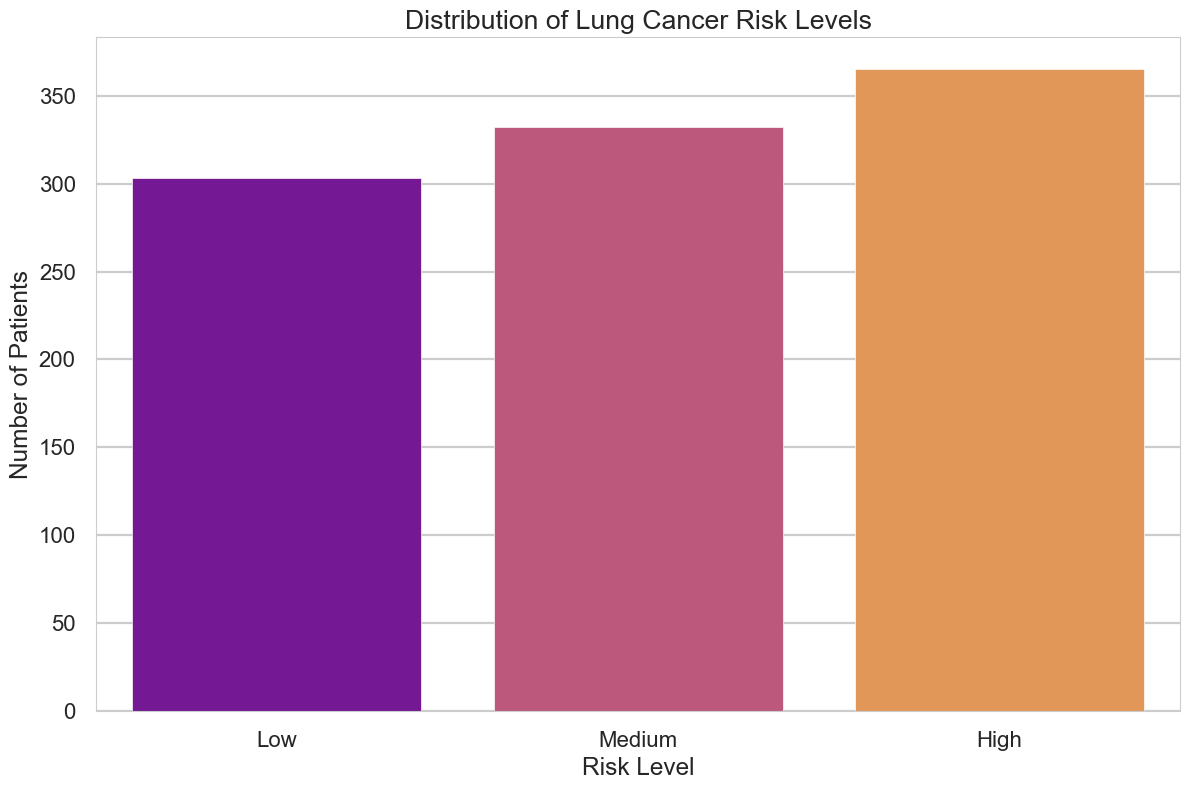

Displayed 'risk_level_distribution' plot.


In [18]:
# c) Distribution of Cancer Risk Level
# Let's see how many patients fall into each risk category.
print("\nPlotting the distribution of cancer risk levels...")
plt.figure(figsize=(12, 8))
sns.countplot(x='Level', data=df, order=['Low', 'Medium', 'High'], palette='plasma', hue='Level', legend=False)
plt.title('Distribution of Lung Cancer Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()
print("Displayed 'risk_level_distribution' plot.")



Plotting gender distribution...


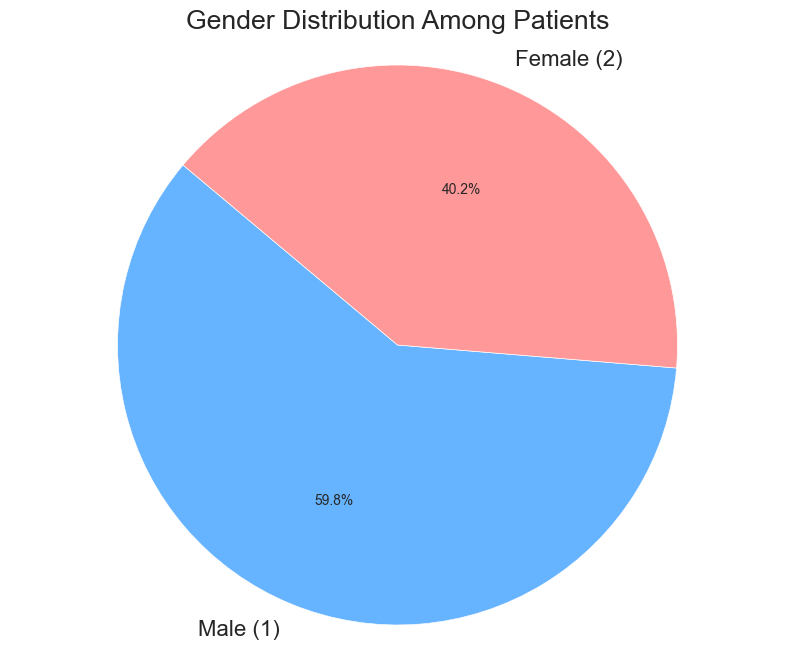

Displayed 'gender_distribution' pie chart.


In [19]:
# d) Gender Distribution (NEW PLOT 1)
# A pie chart is great for showing proportions.
print("\nPlotting gender distribution...")
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(gender_counts, labels=['Male (1)', 'Female (2)'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.title('Gender Distribution Among Patients')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()
print("Displayed 'gender_distribution' pie chart.")



Plotting the age distribution of patients...


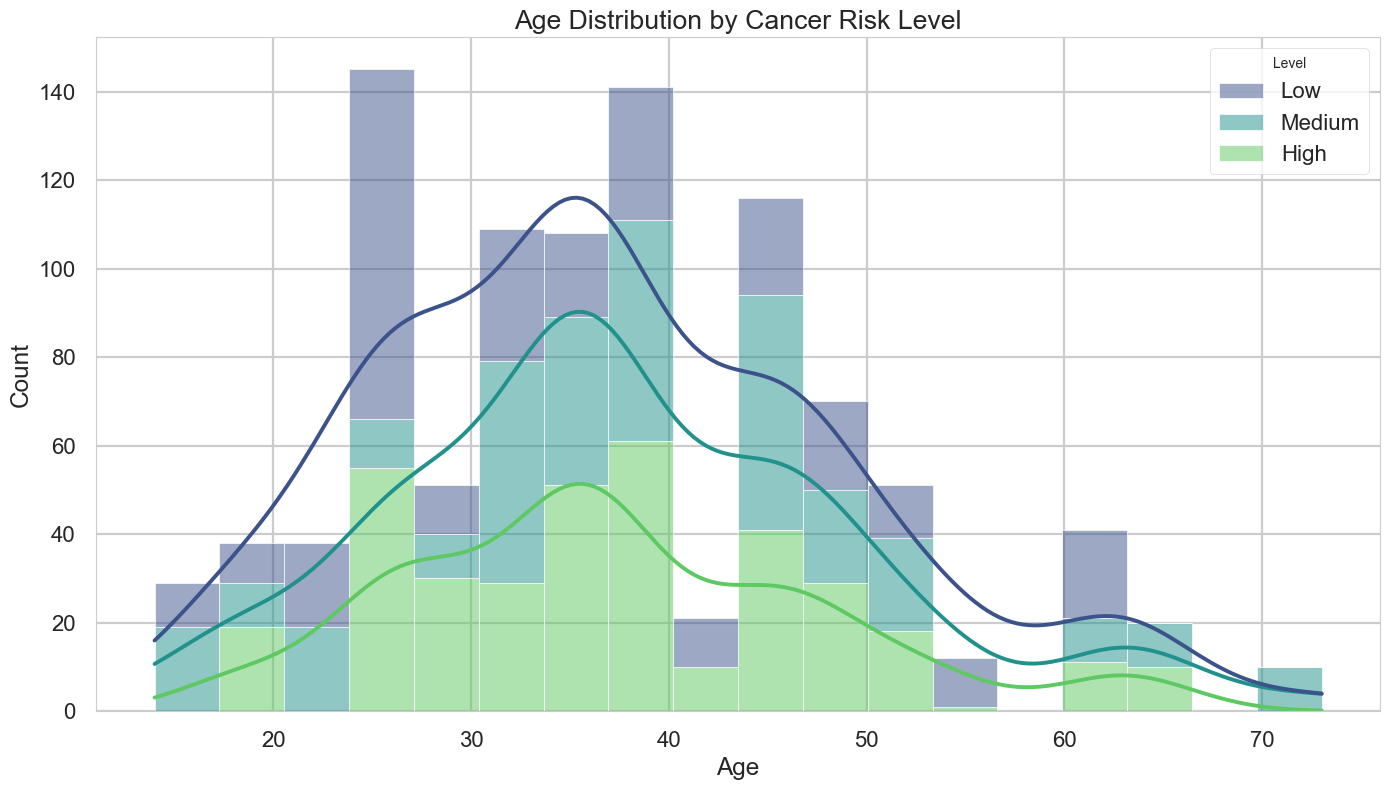

Displayed 'age_distribution' plot.


In [20]:
# e) Age Distribution Analysis
# Understanding the age distribution can provide demographic insights.
print("\nPlotting the age distribution of patients...")
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='Age', hue='Level', kde=True, palette='viridis', multiple="stack")
plt.title('Age Distribution by Cancer Risk Level')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("Displayed 'age_distribution' plot.")


Generating Box Plots for every feature vs. risk level...


C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


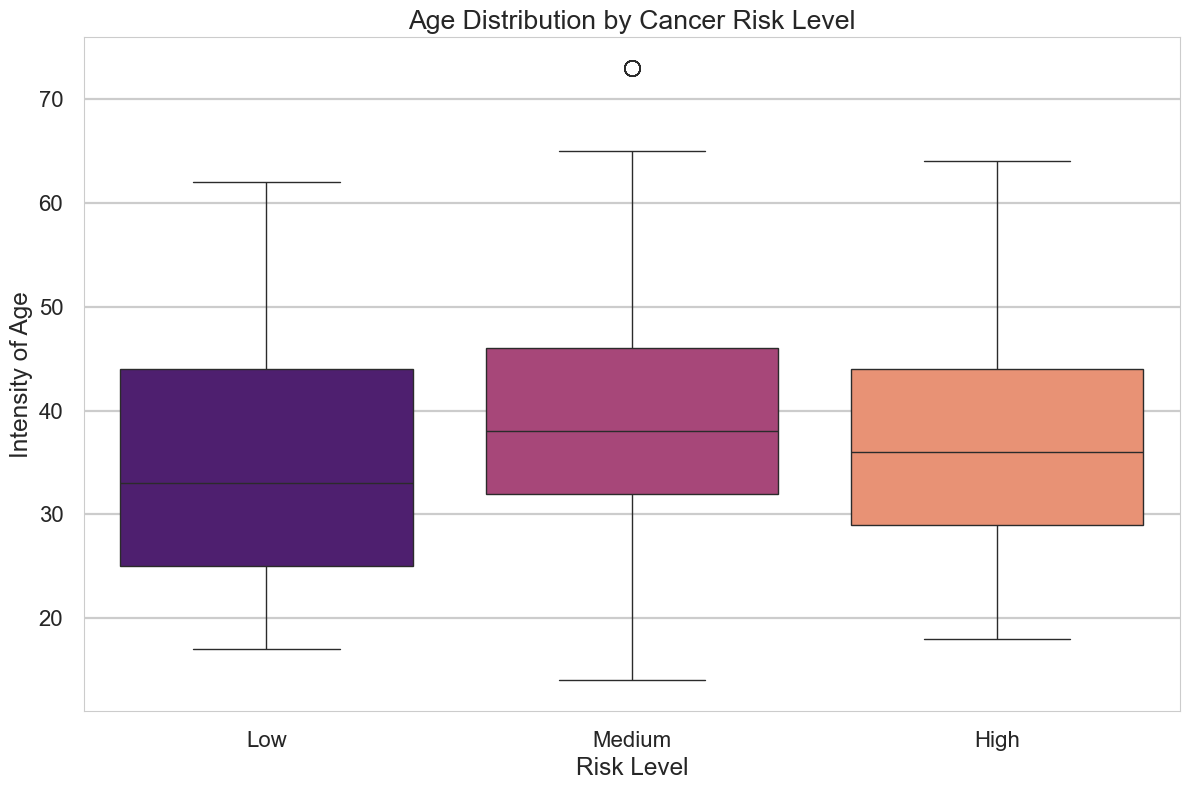

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


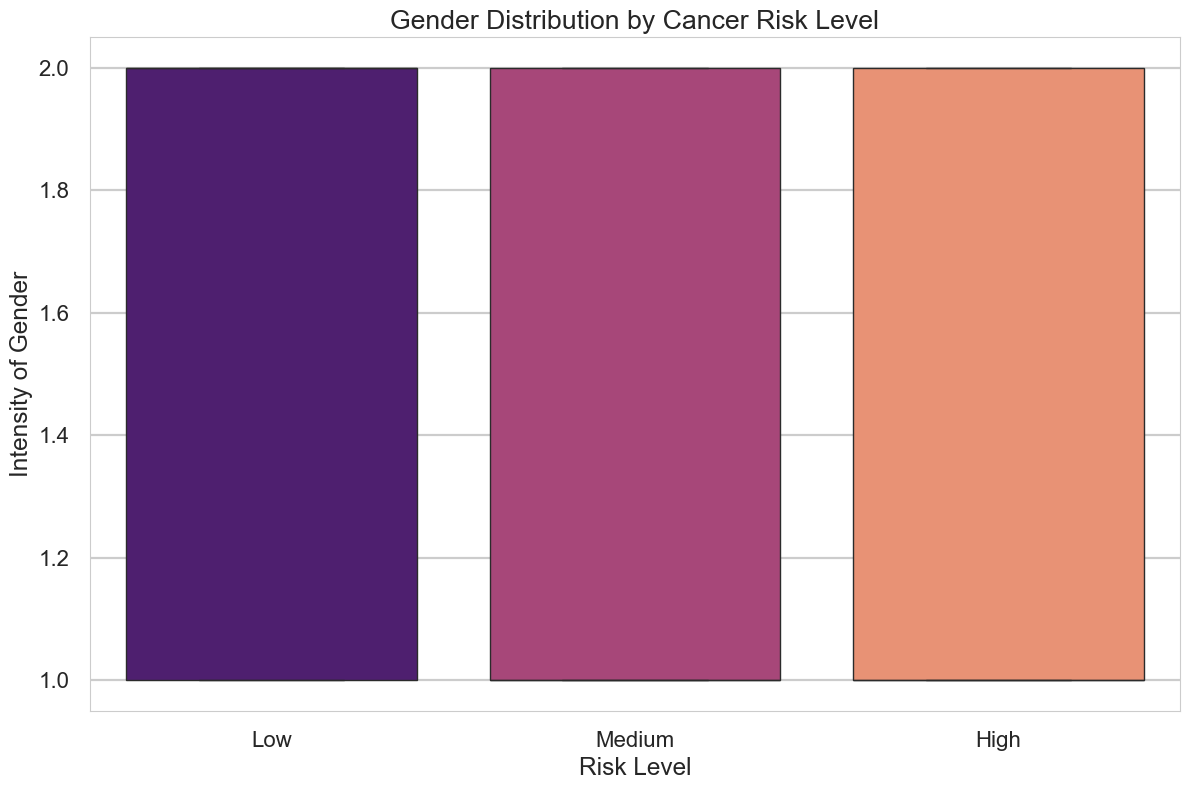

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


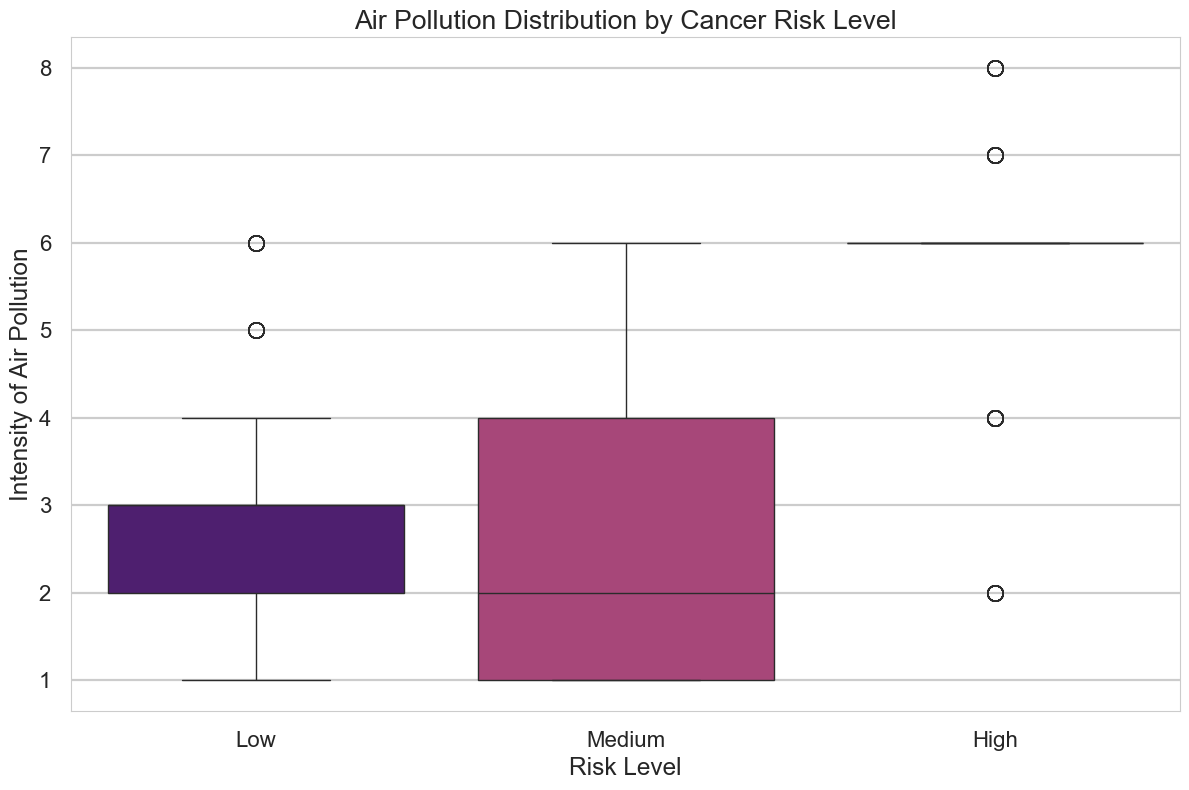

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


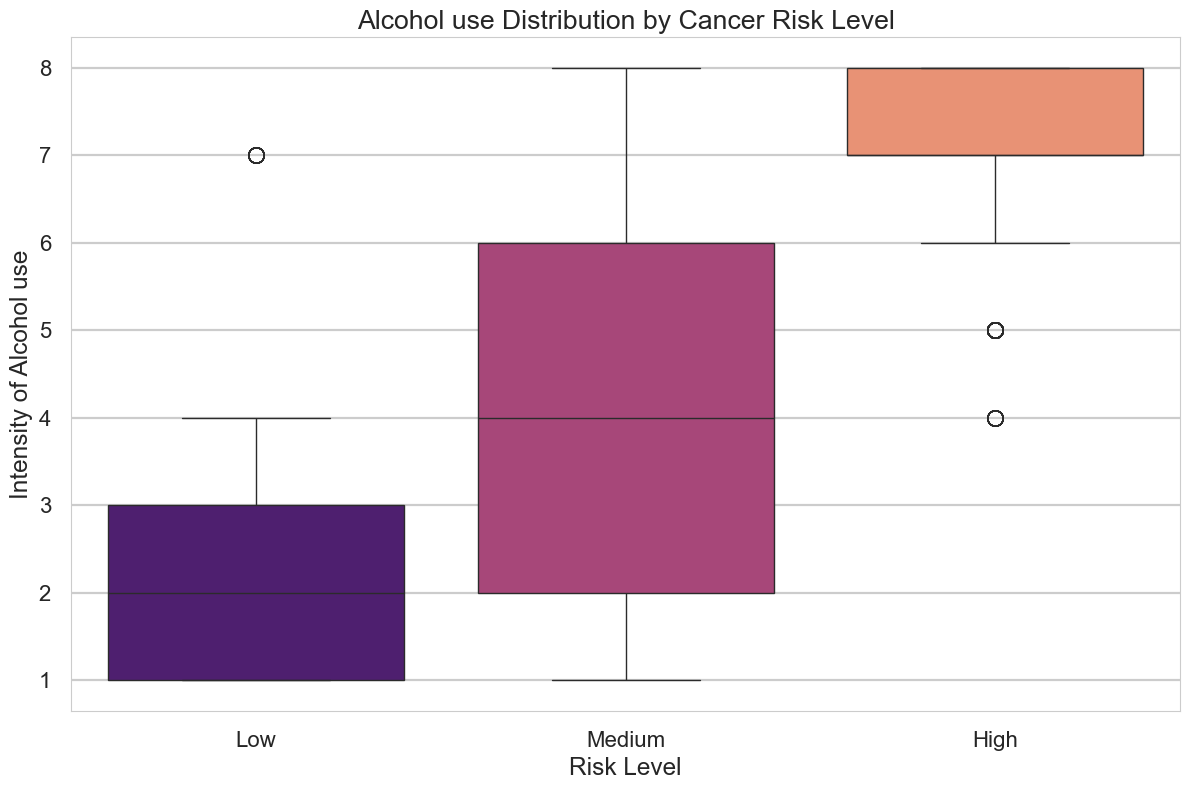

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


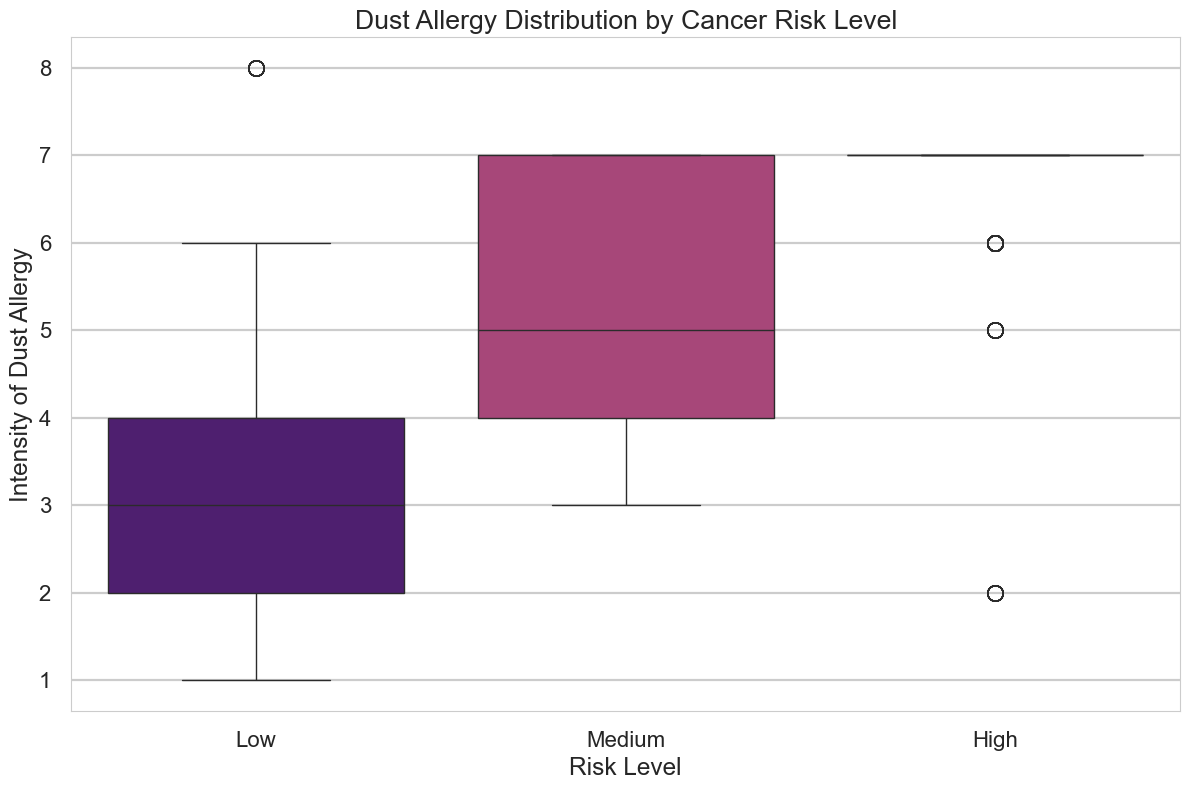

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


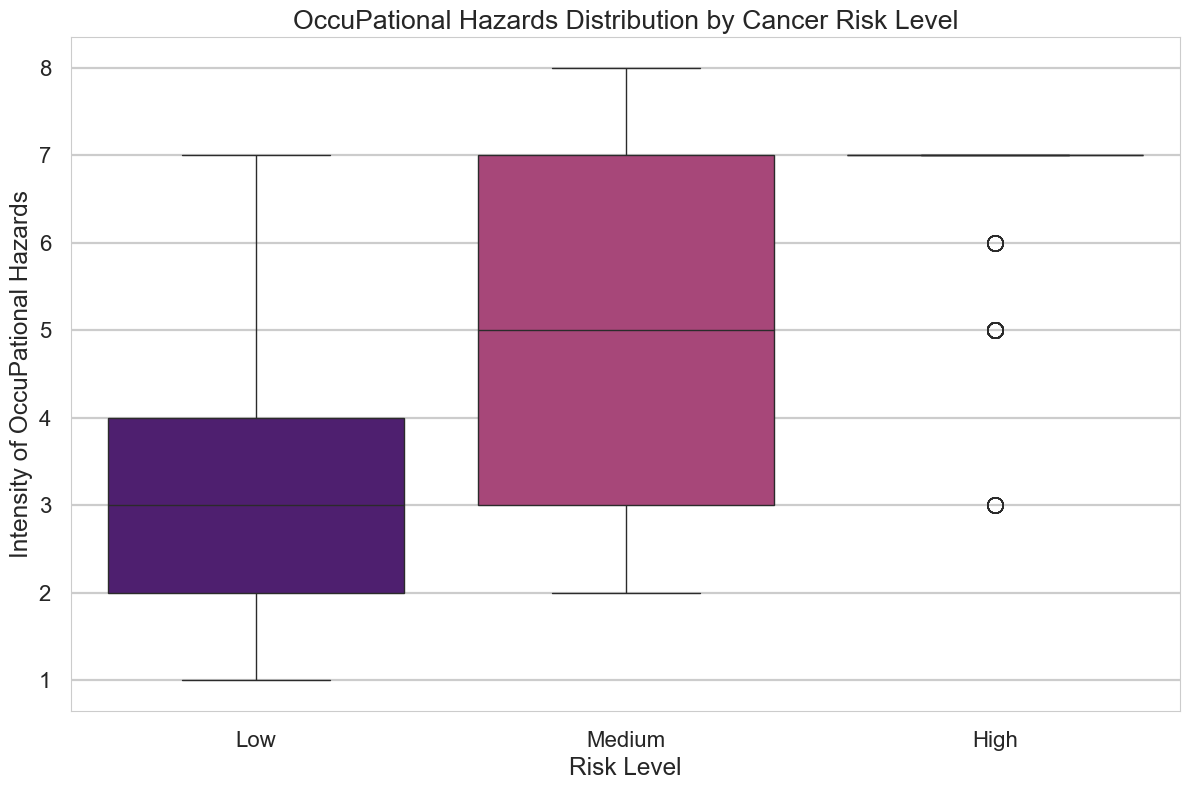

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


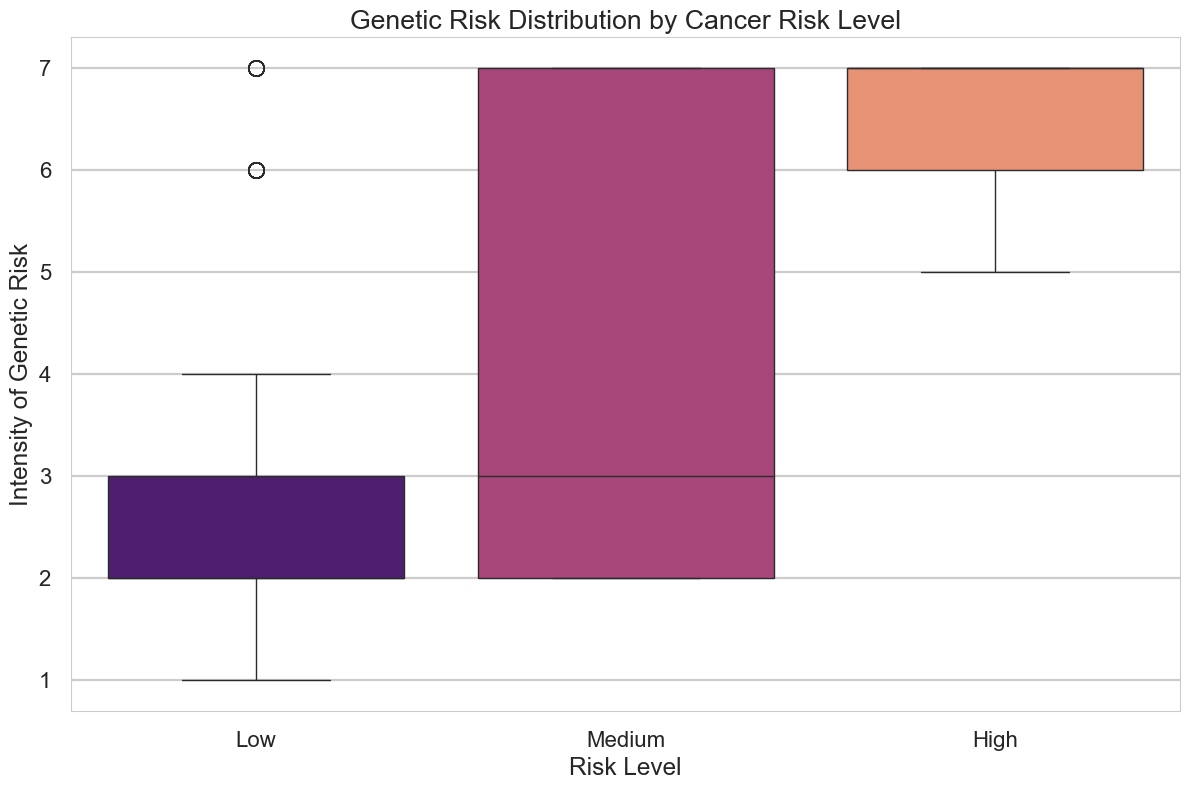

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


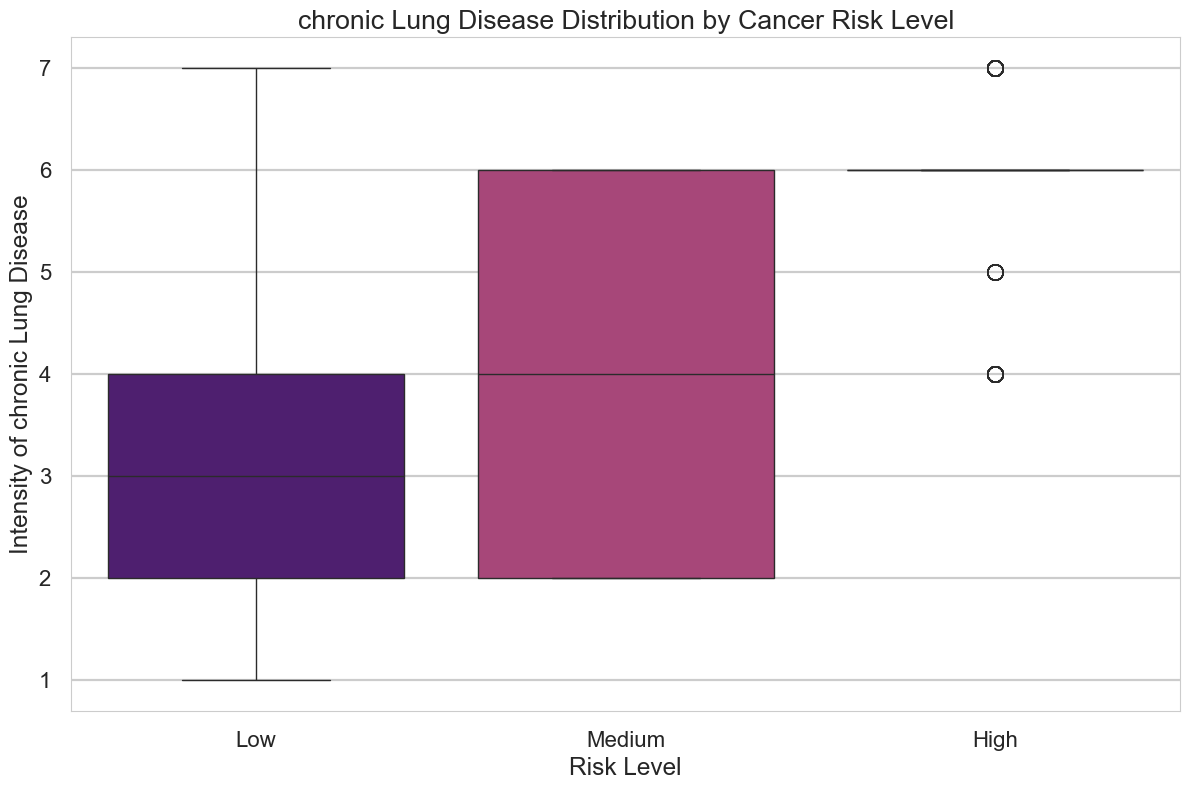

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


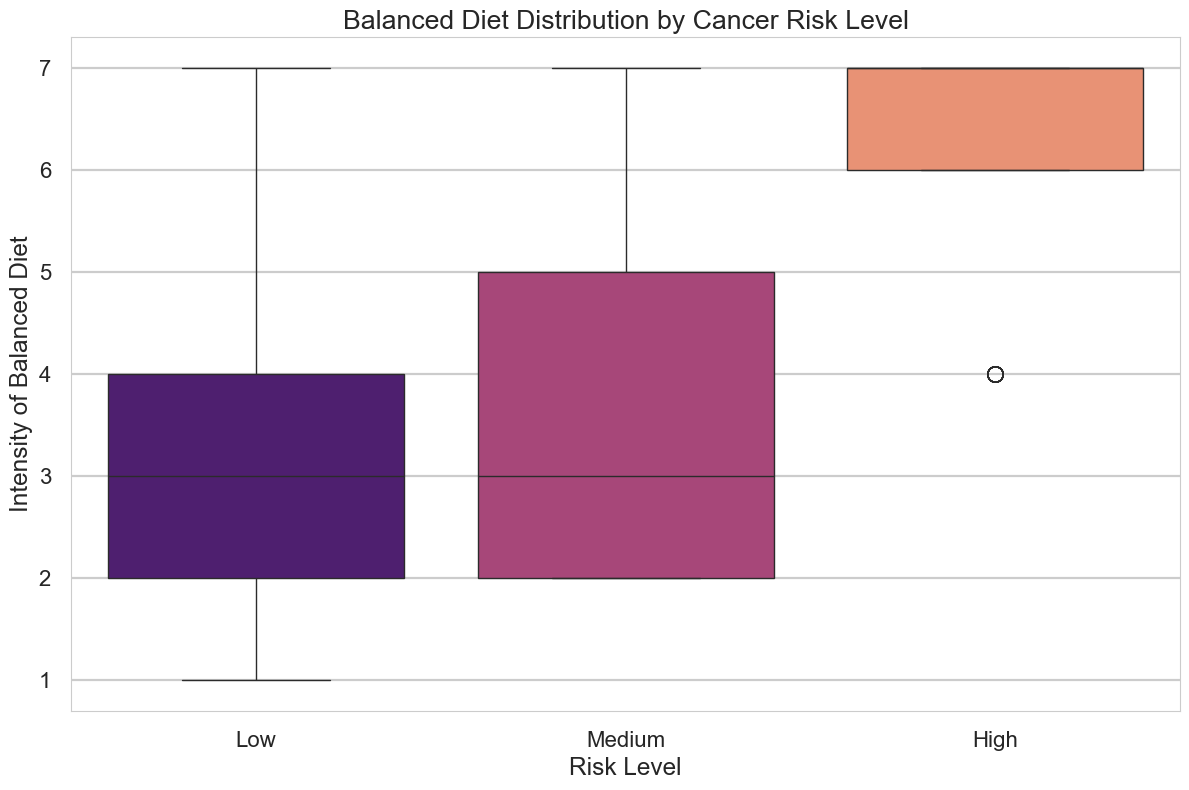

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


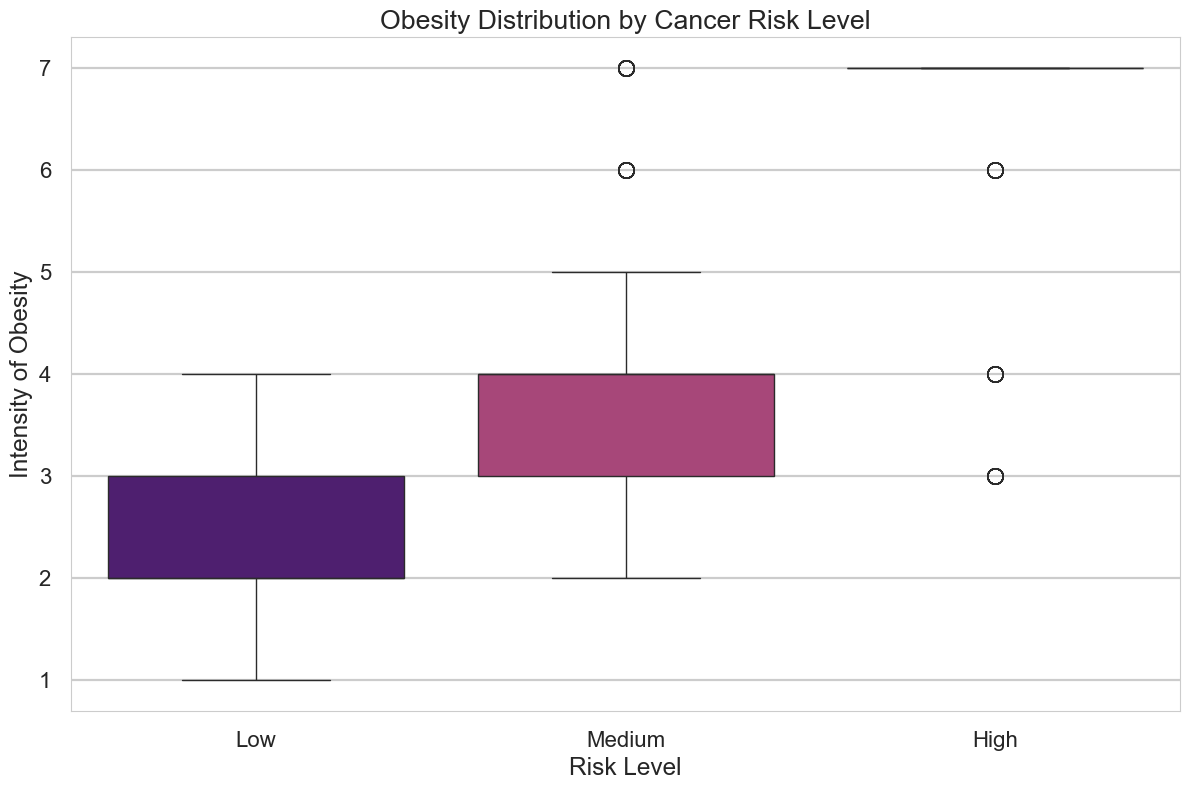

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


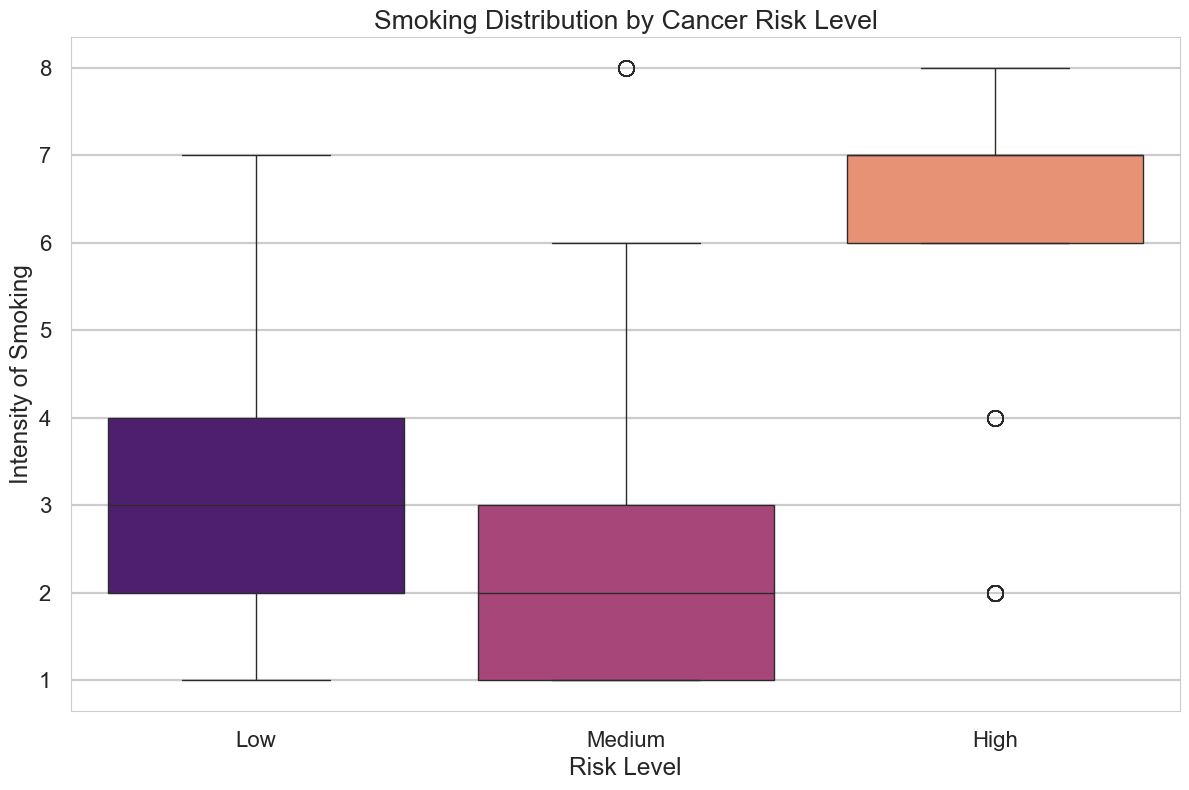

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


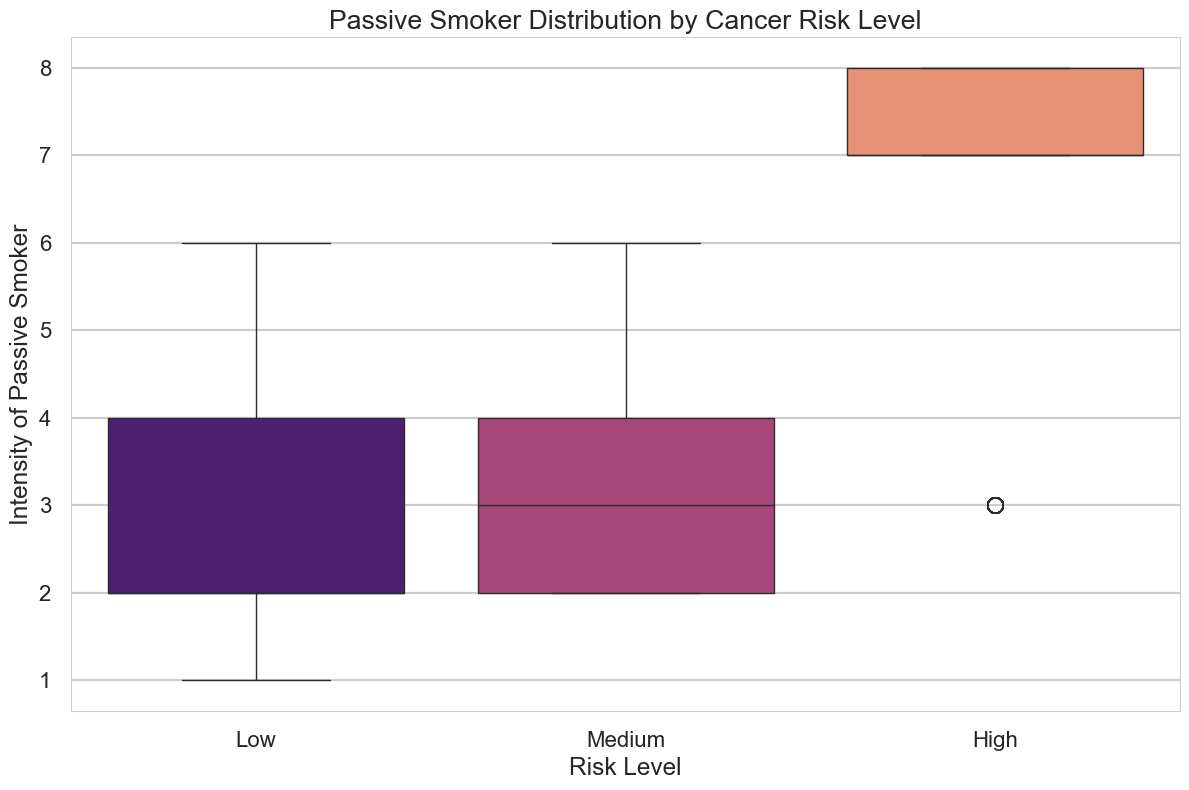

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


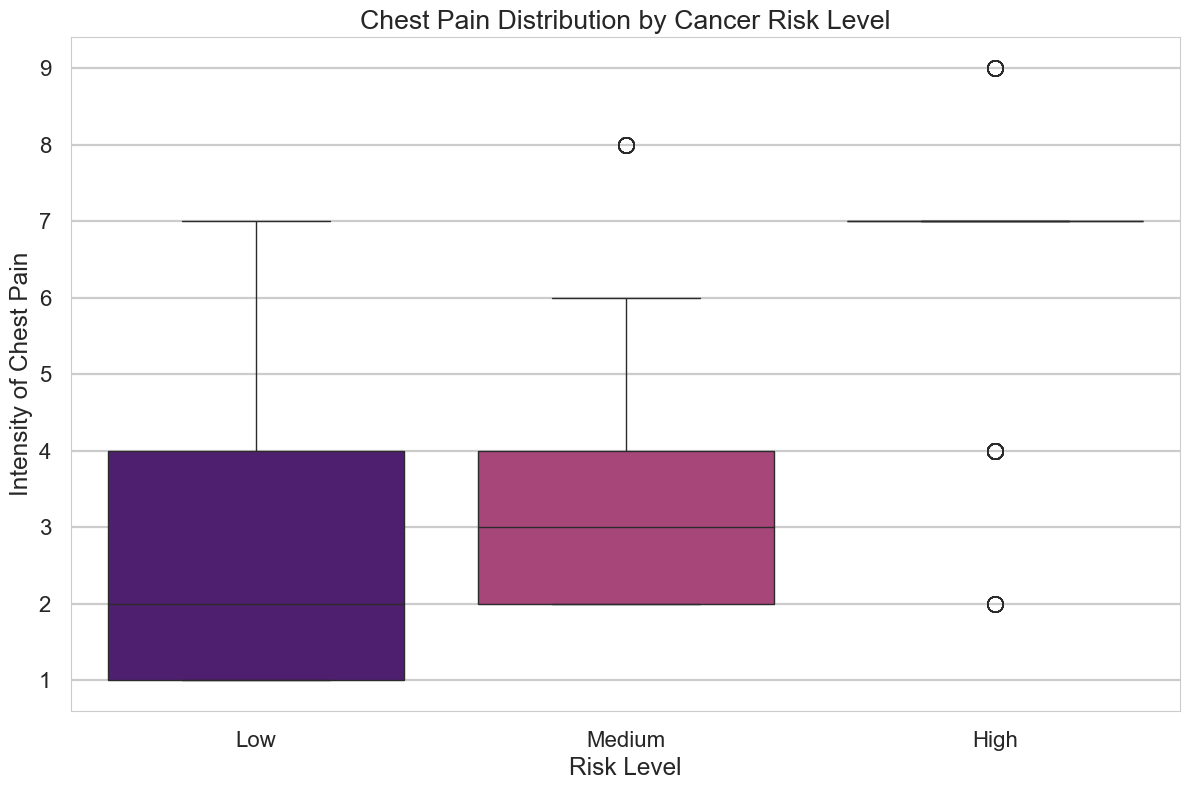

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


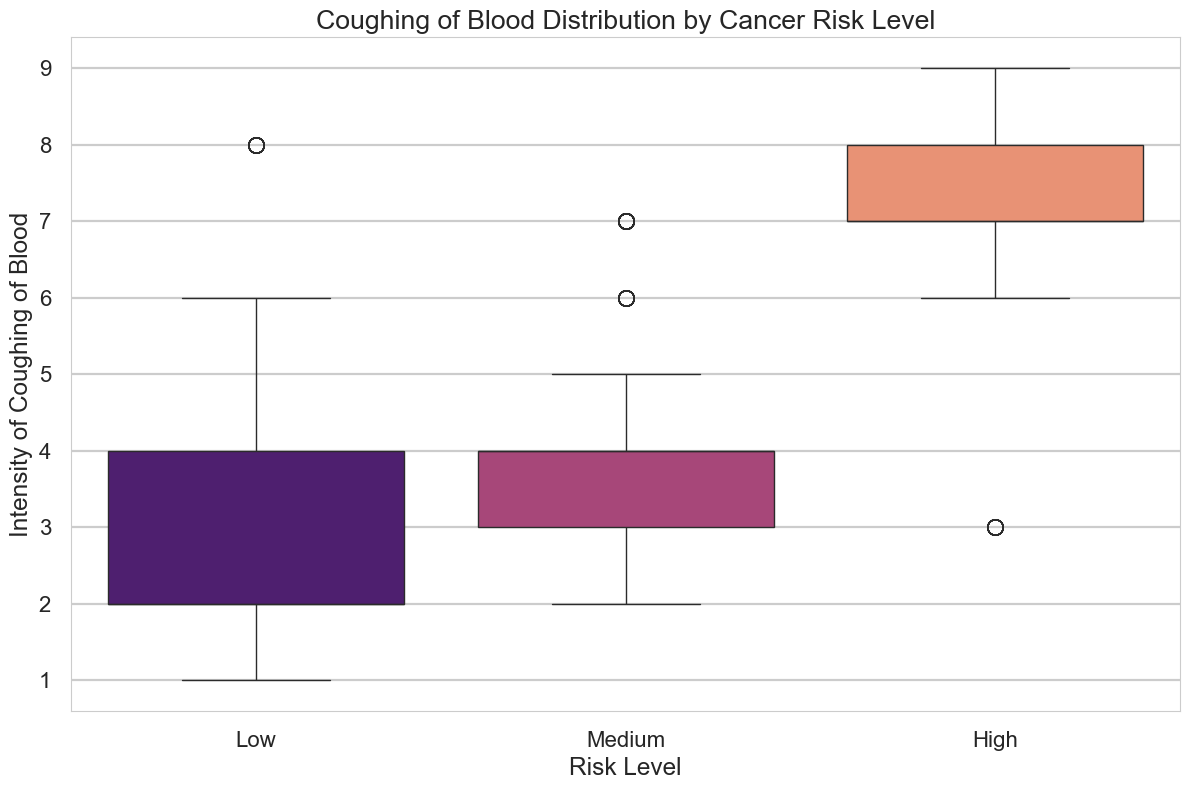

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


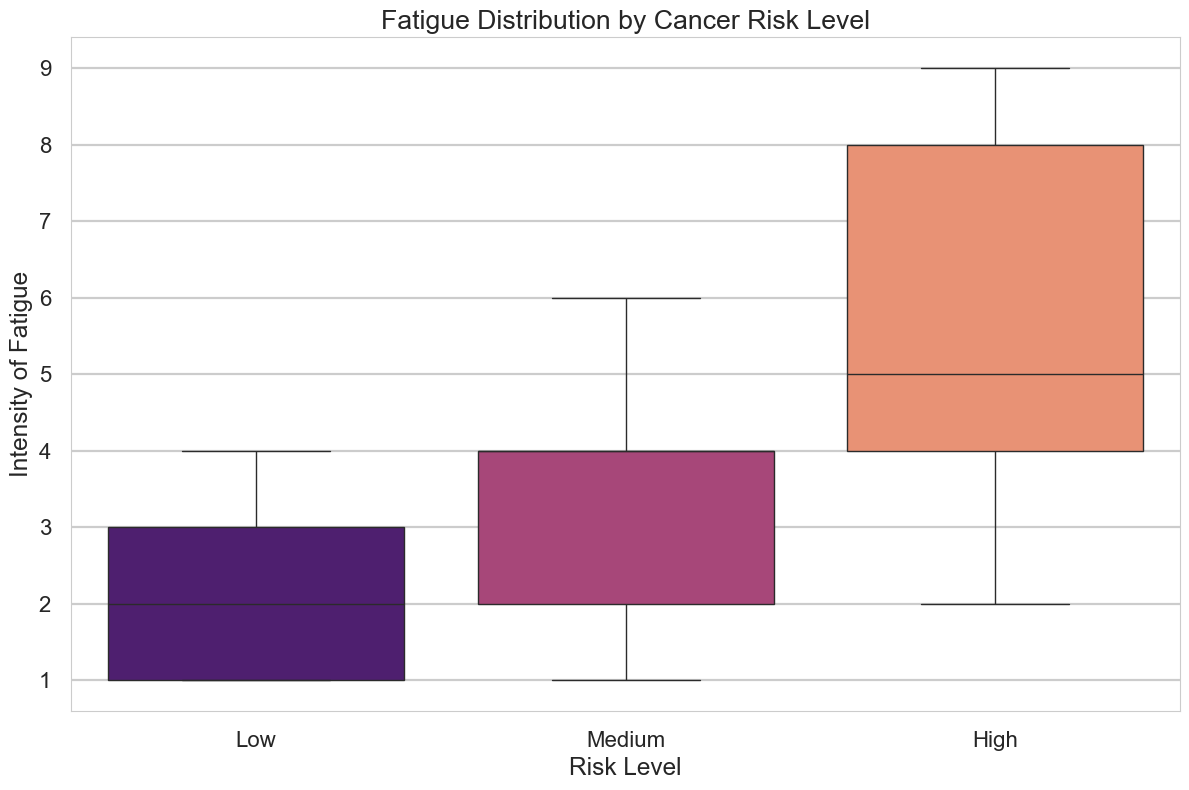

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


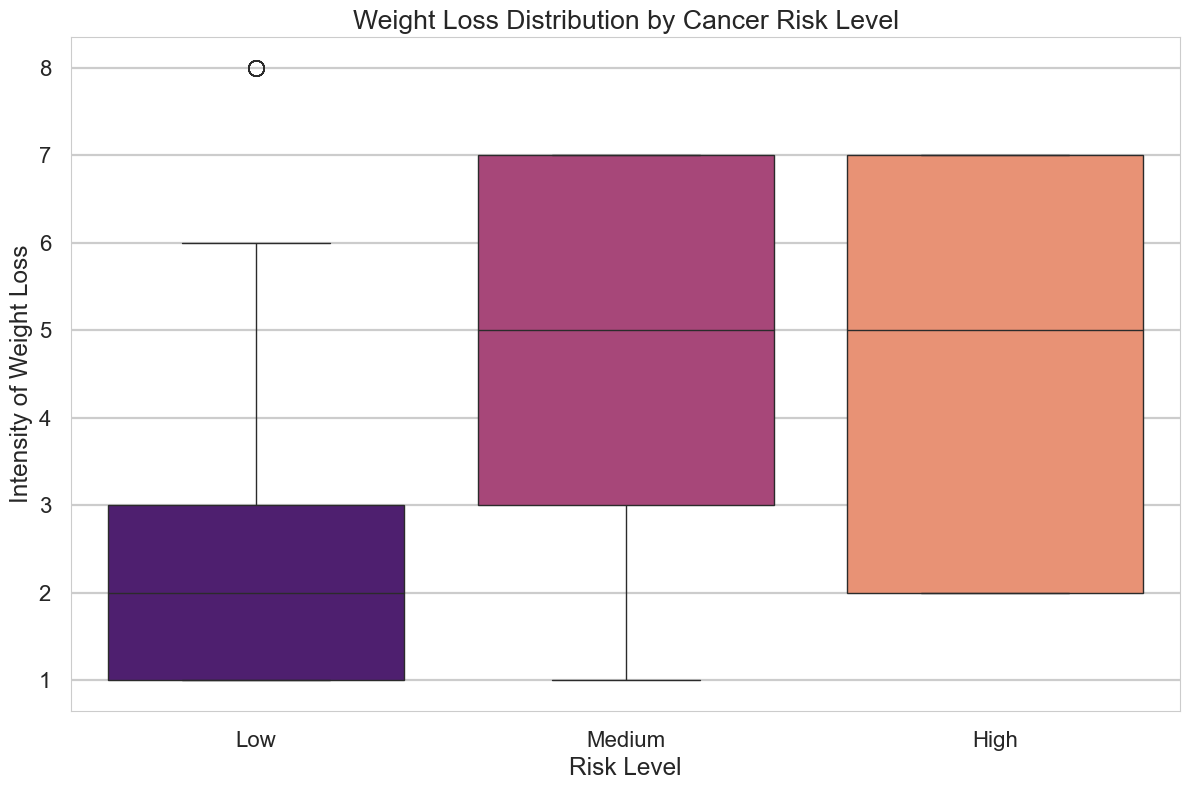

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


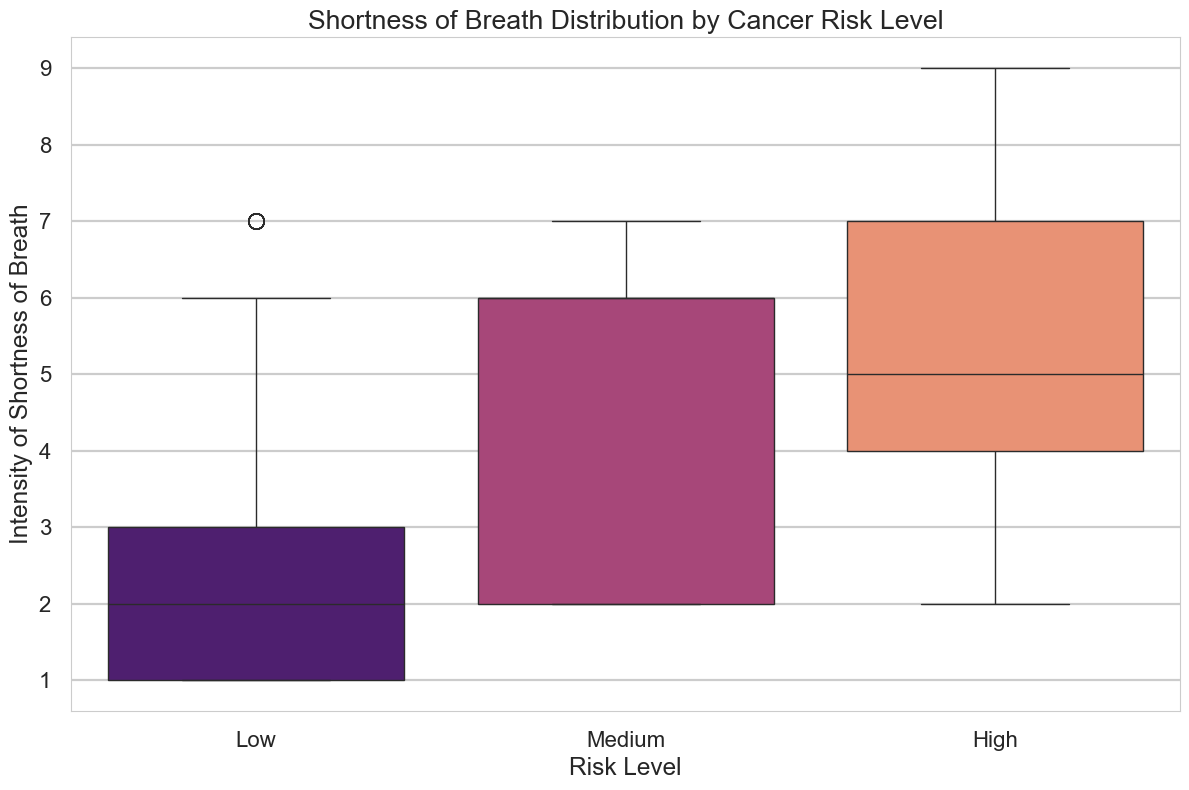

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


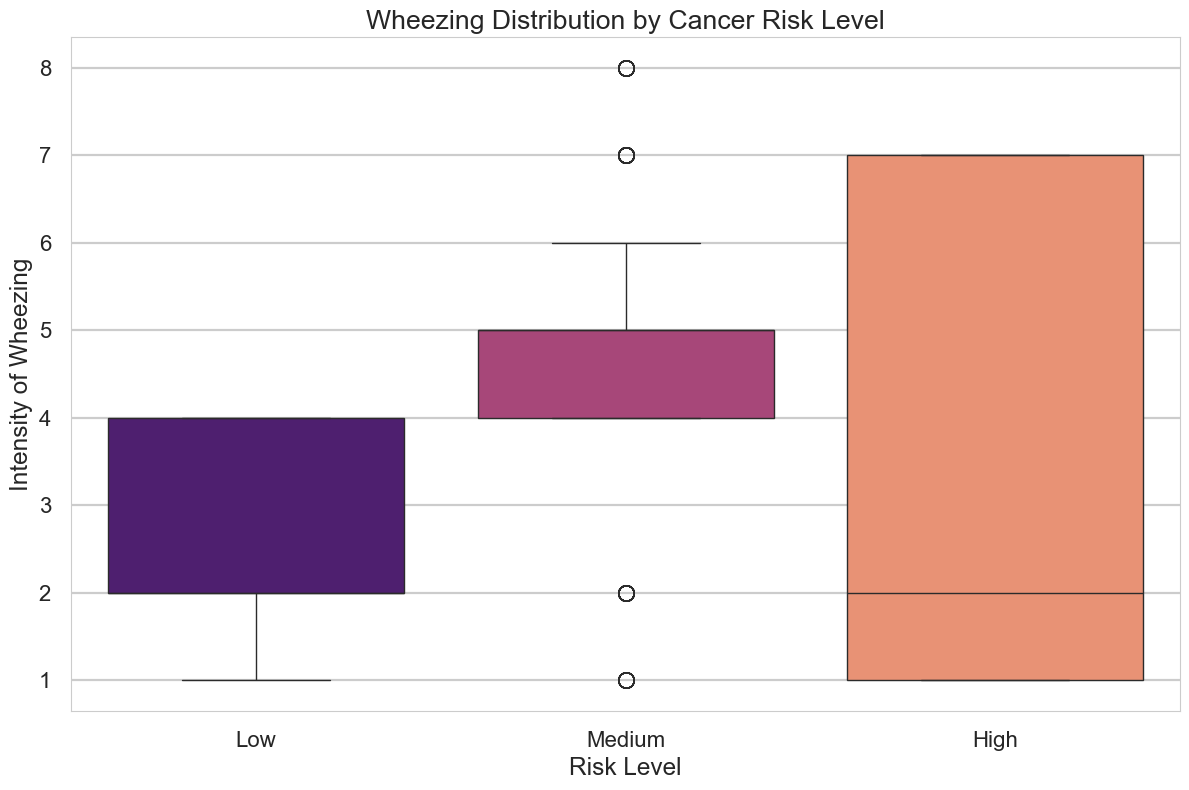

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


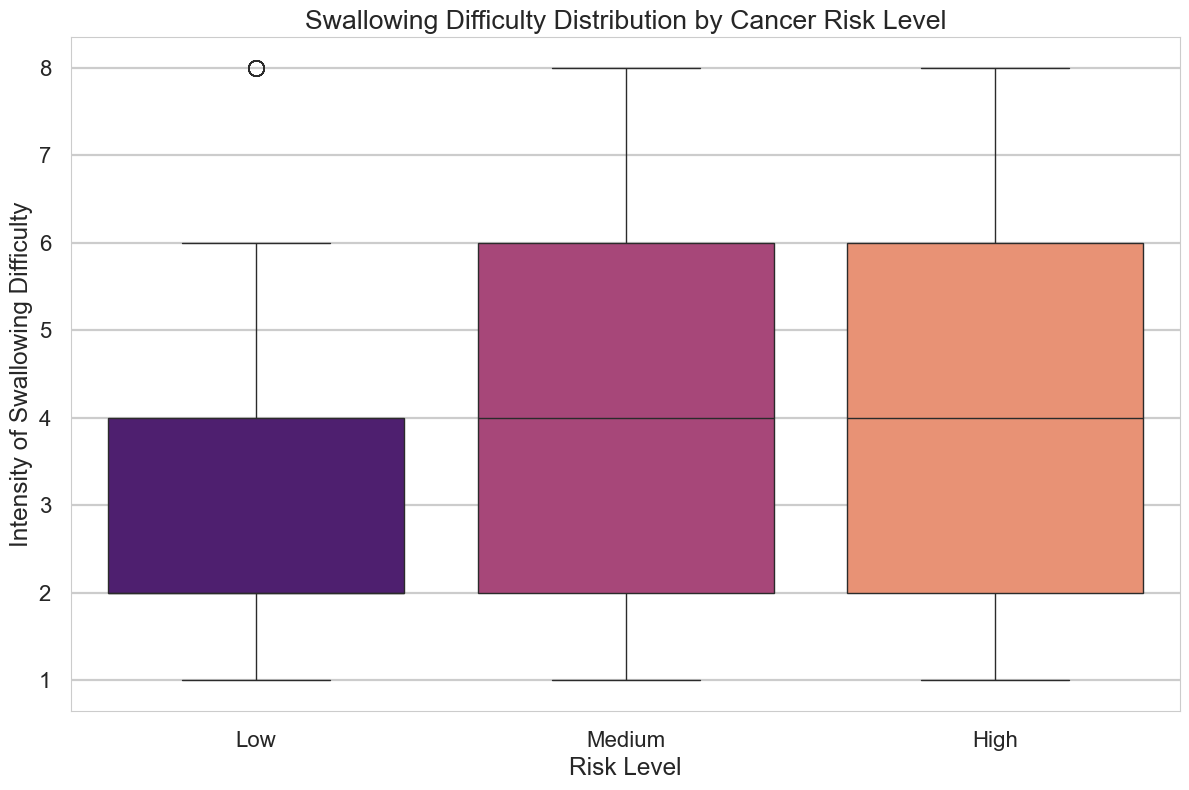

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


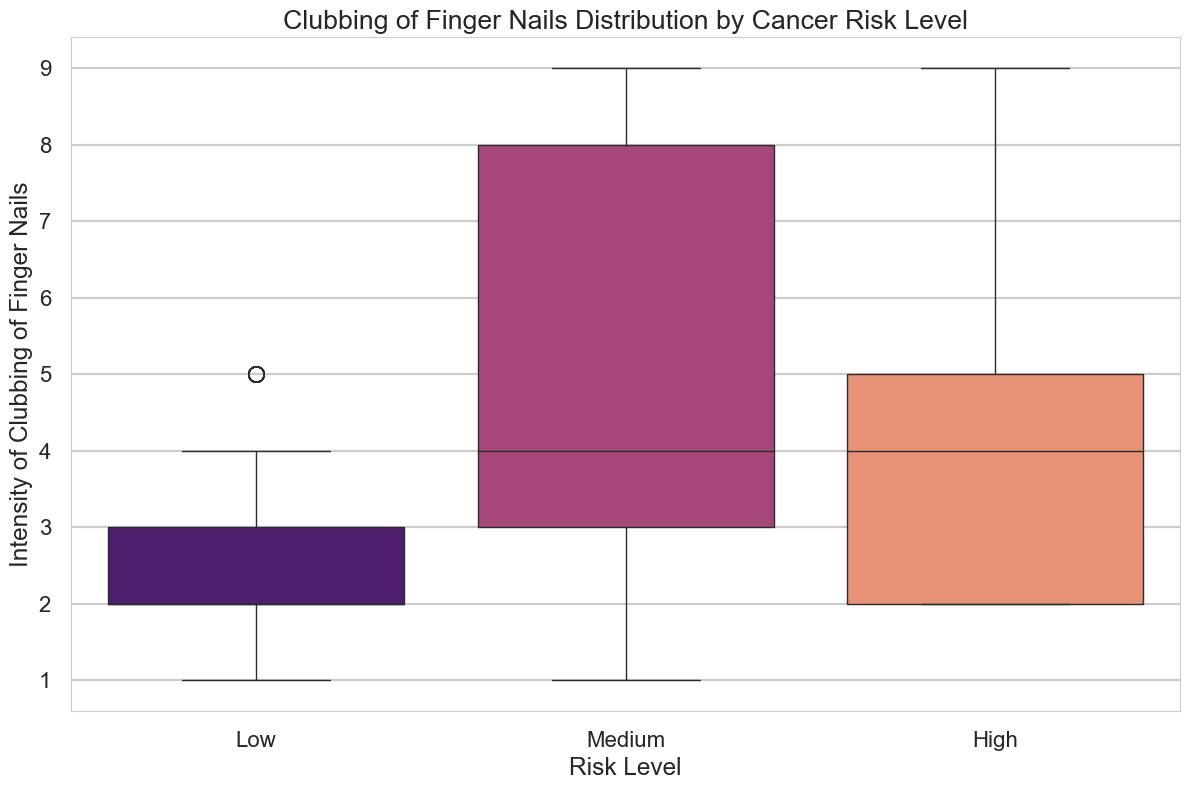

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


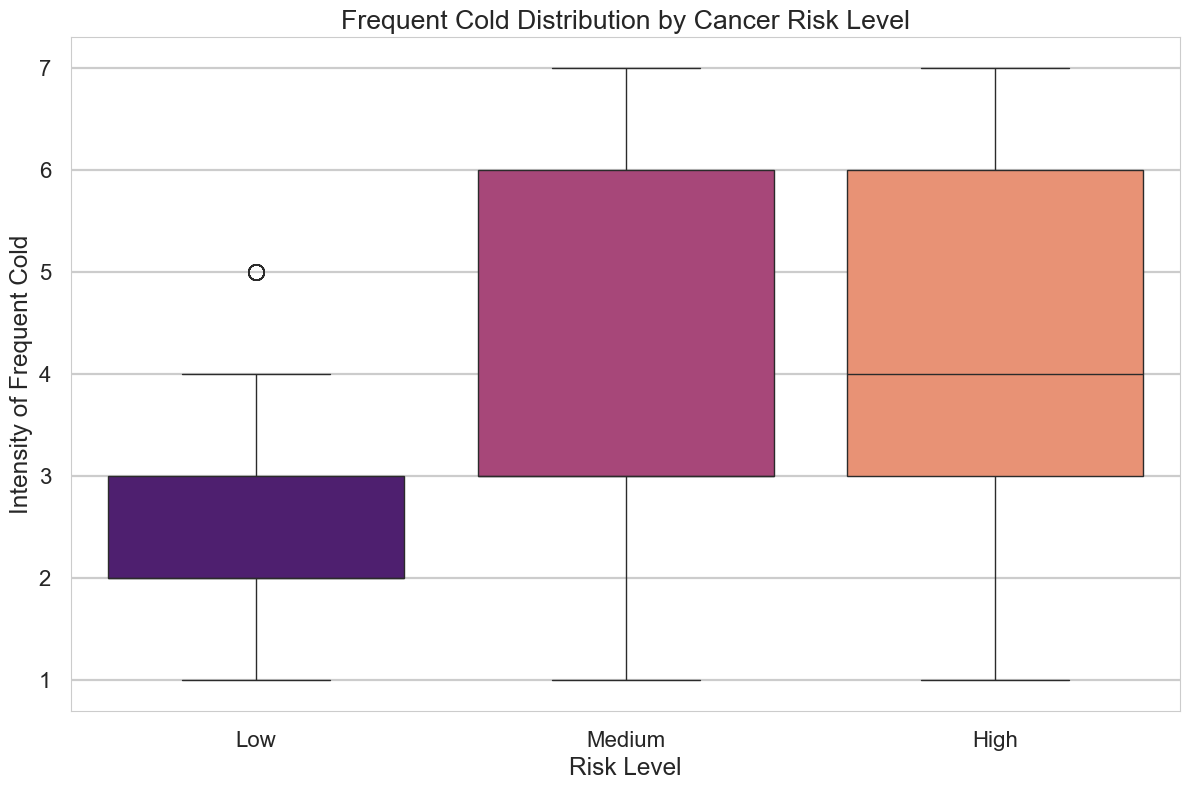

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


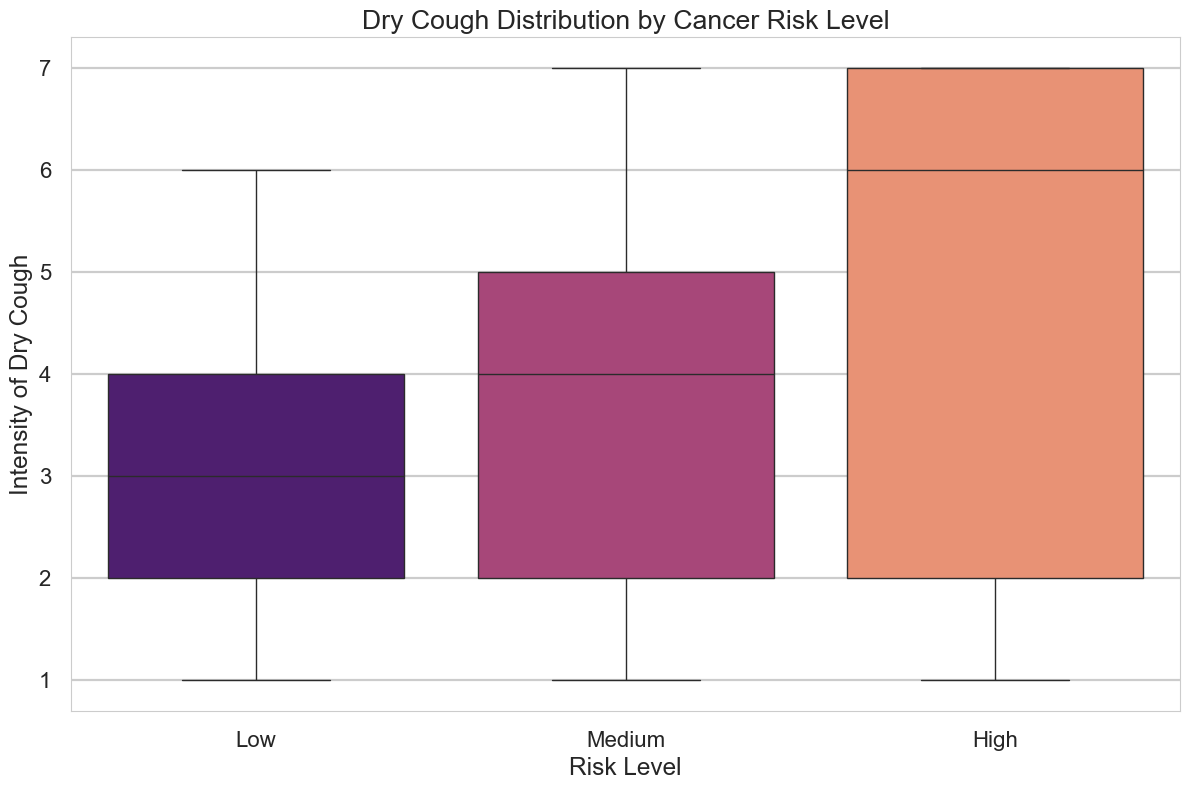

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\702225752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')


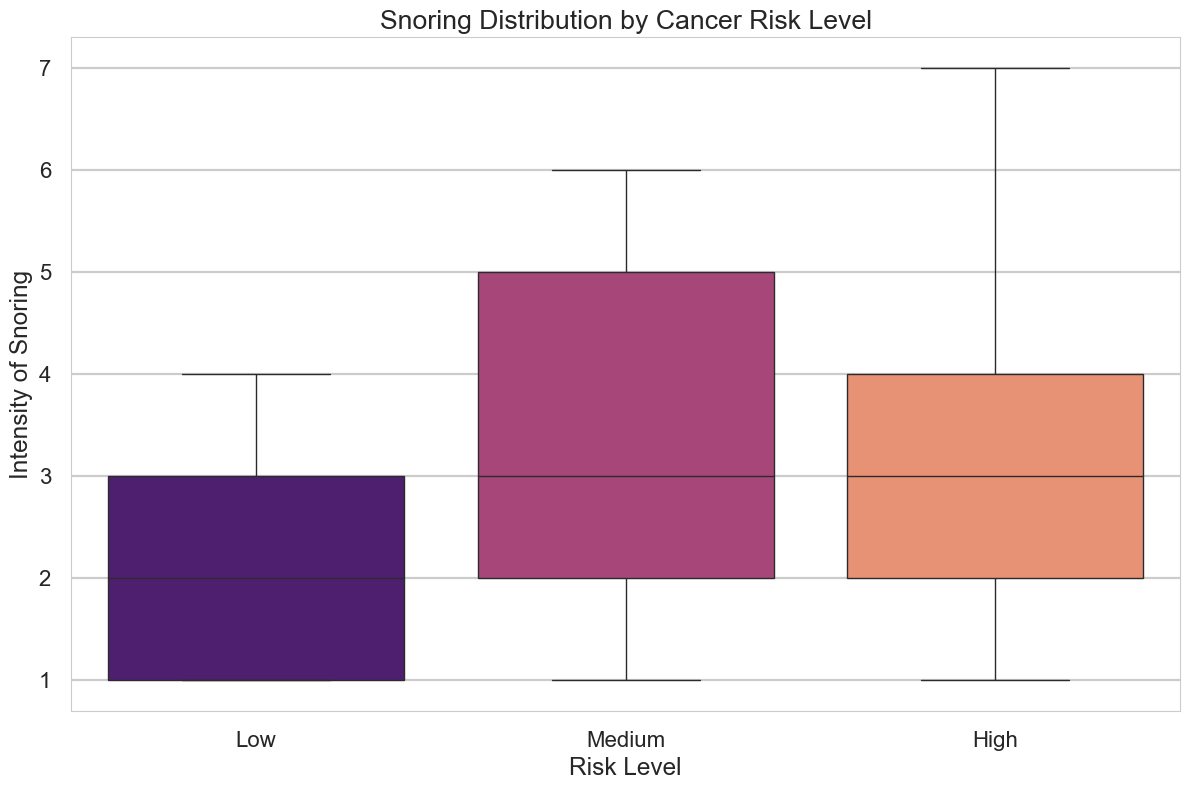

Displayed box plots for all features.


In [21]:
# f) Box Plots for All Features vs. Risk Level (NEW PLOTS 2-24)
# This is a deep dive to compare the distribution of every single factor
# across the different risk levels.
print("\nGenerating Box Plots for every feature vs. risk level...")
features_to_plot = df.drop(['Level', 'Level_encoded'], axis=1).columns
for feature in features_to_plot:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='magma')
    plt.title(f'{feature} Distribution by Cancer Risk Level')
    plt.xlabel('Risk Level')
    plt.ylabel(f'Intensity of {feature}')
    plt.tight_layout()
    plt.show()
print("Displayed box plots for all features.")


Plotting the correlation heatmap...


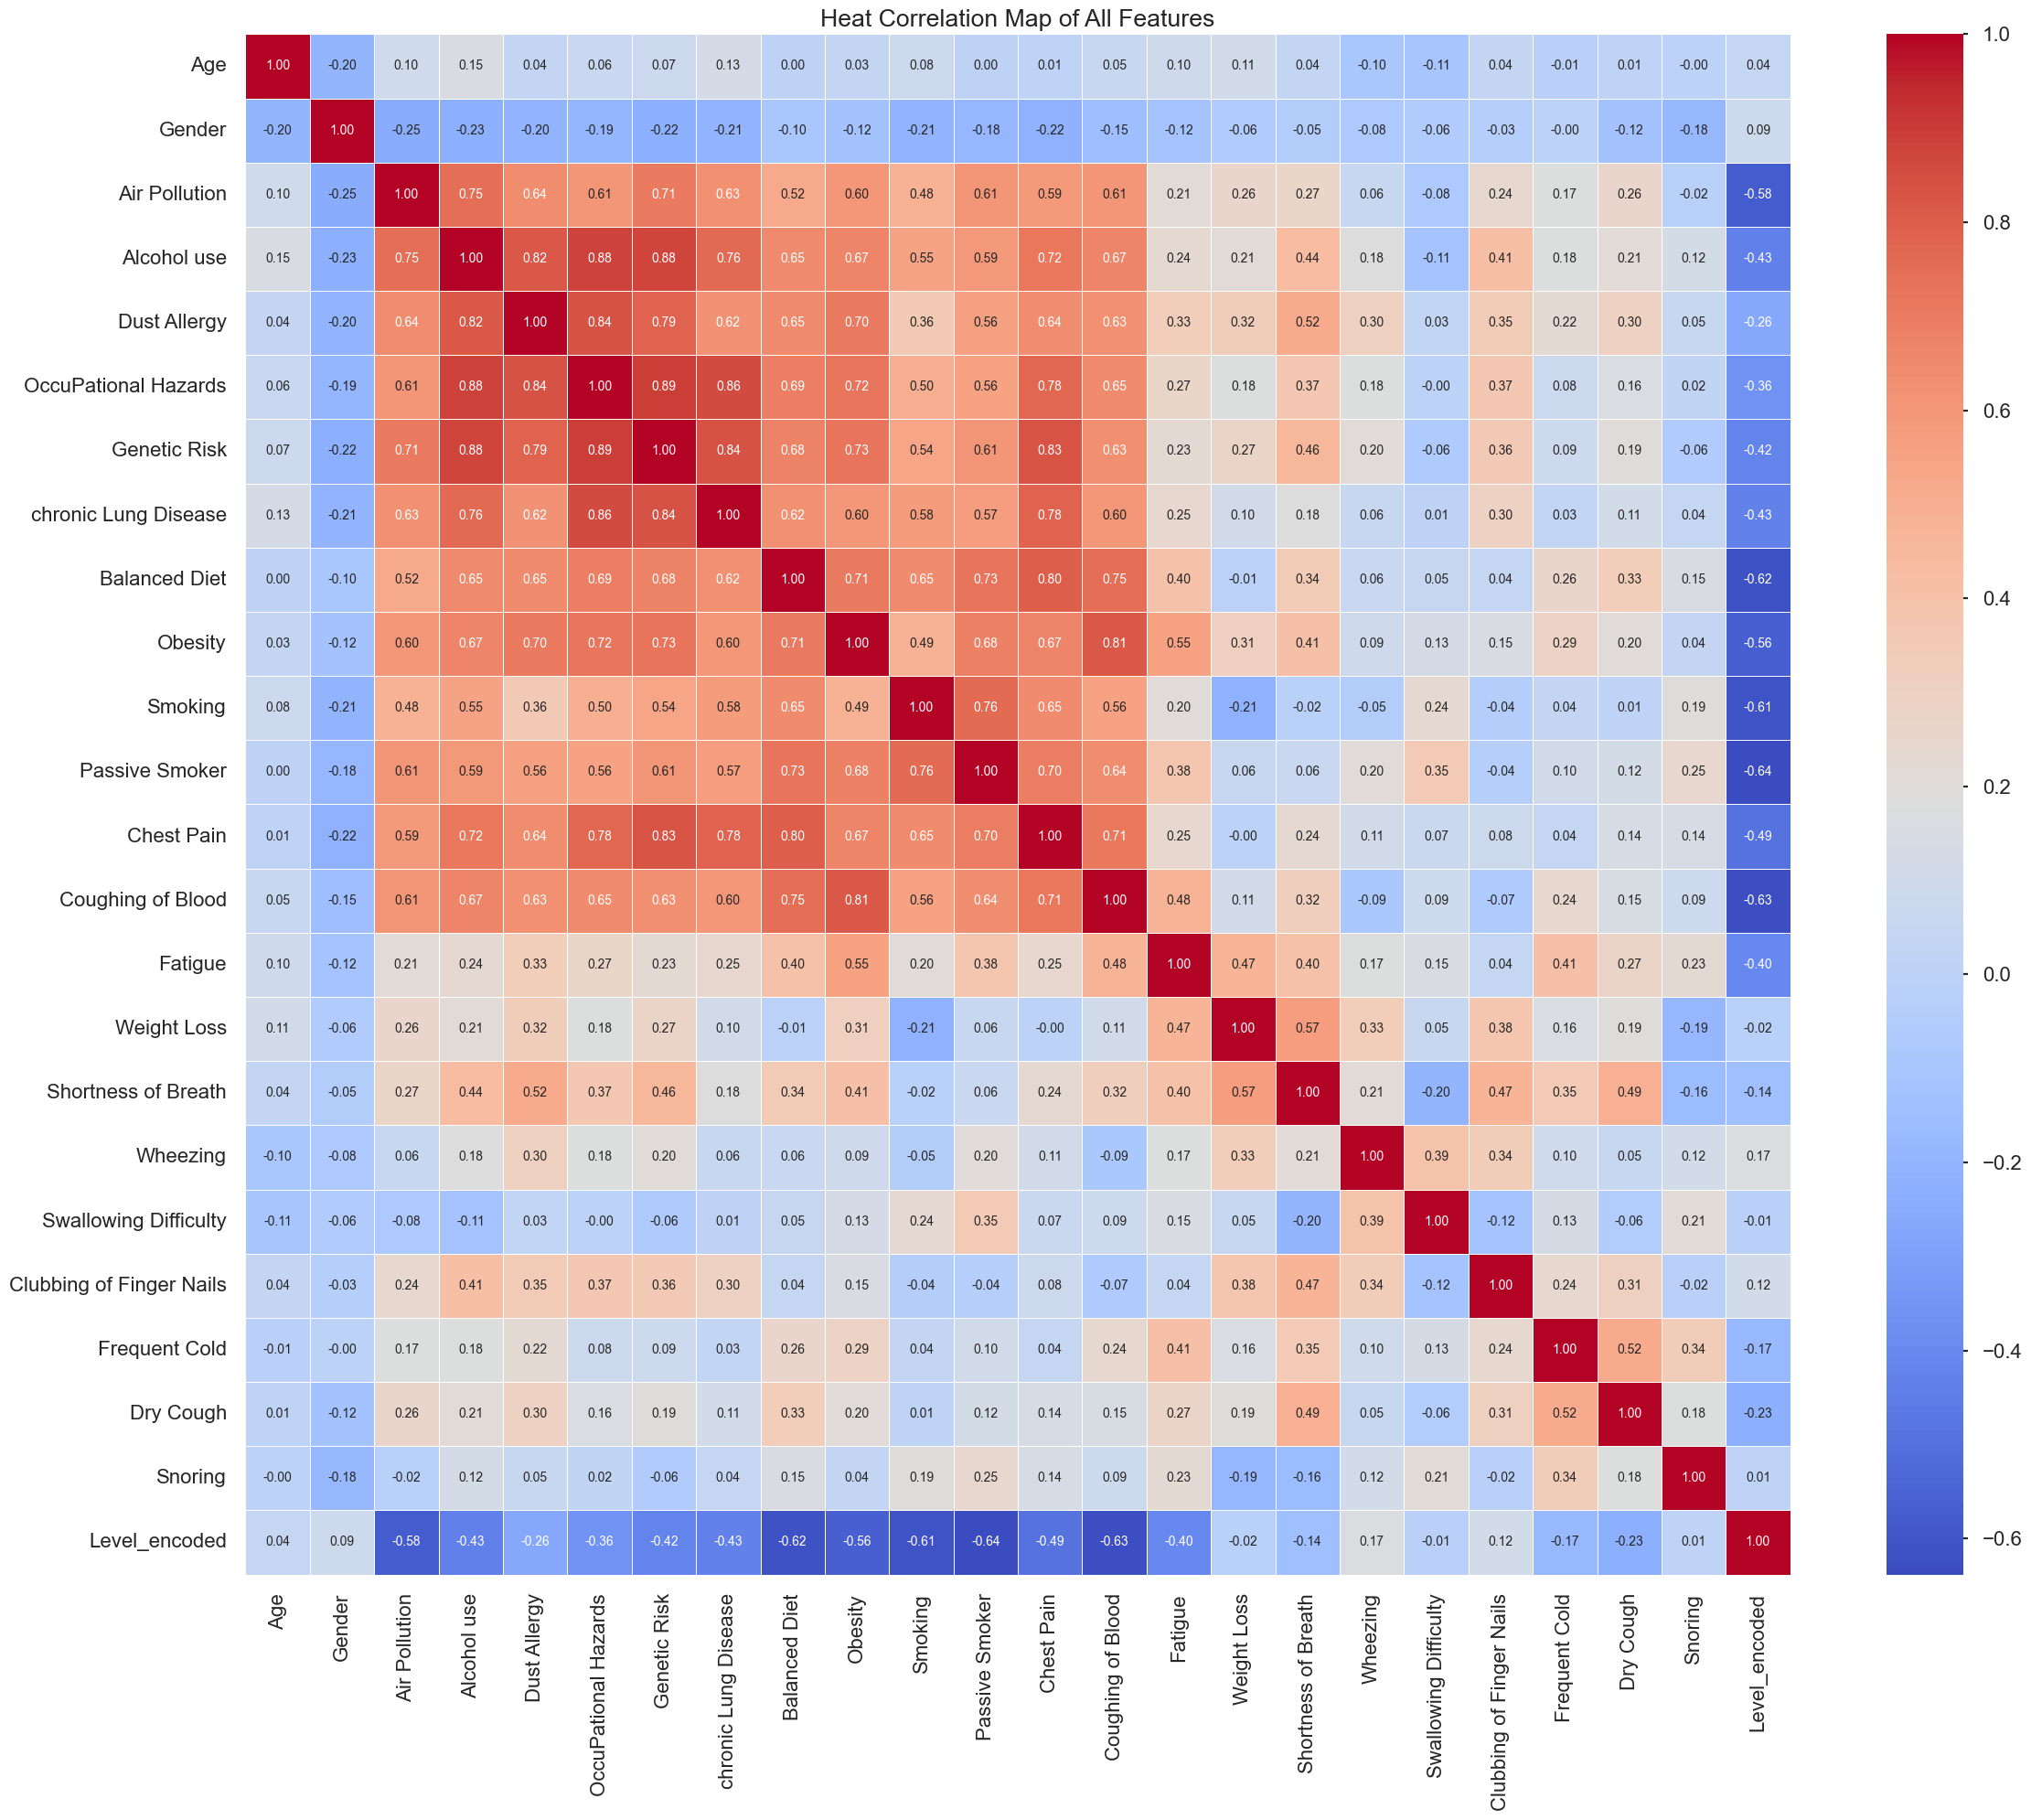

Displayed 'correlation_heatmap' plot.


In [22]:
# g) Correlation Heatmap
# A heatmap shows us how strongly each feature is related to others.
# Red means a strong positive correlation, blue means a strong negative one.
print("\nPlotting the correlation heatmap...")
plt.figure(figsize=(24, 20))
sns.heatmap(df.drop('Level', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heat Correlation Map of All Features')
plt.tight_layout()
plt.show()
print("Displayed 'correlation_heatmap' plot.")


Generating Swarm Plot for Age vs. Risk Level...


C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2573522151.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Level', y='Age', data=df, order=['Low', 'Medium', 'High'], palette='coolwarm')


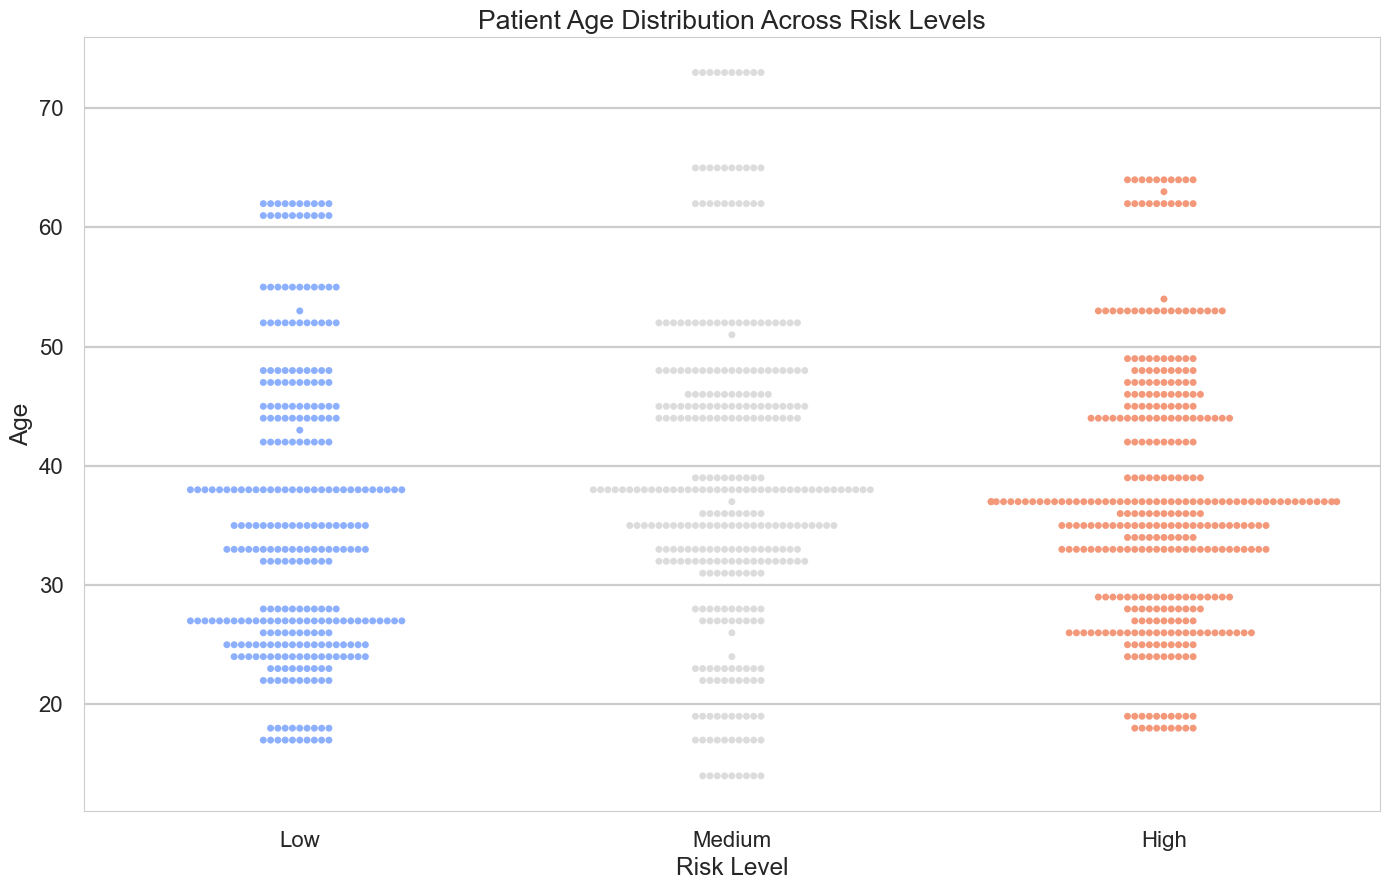

Displayed 'swarm_plot' for Age.


In [23]:
# h) Swarm Plot for Age vs. Risk (NEW PLOT 25)
# A swarm plot shows individual data points, which can reveal distributions
# in a way that box plots can't.
print("\nGenerating Swarm Plot for Age vs. Risk Level...")
plt.figure(figsize=(14, 9))
sns.swarmplot(x='Level', y='Age', data=df, order=['Low', 'Medium', 'High'], palette='coolwarm')
plt.title('Patient Age Distribution Across Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Age')
plt.tight_layout()
plt.show()
print("Displayed 'swarm_plot' for Age.")


Plotting violin plots for key features...


C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2013587499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')


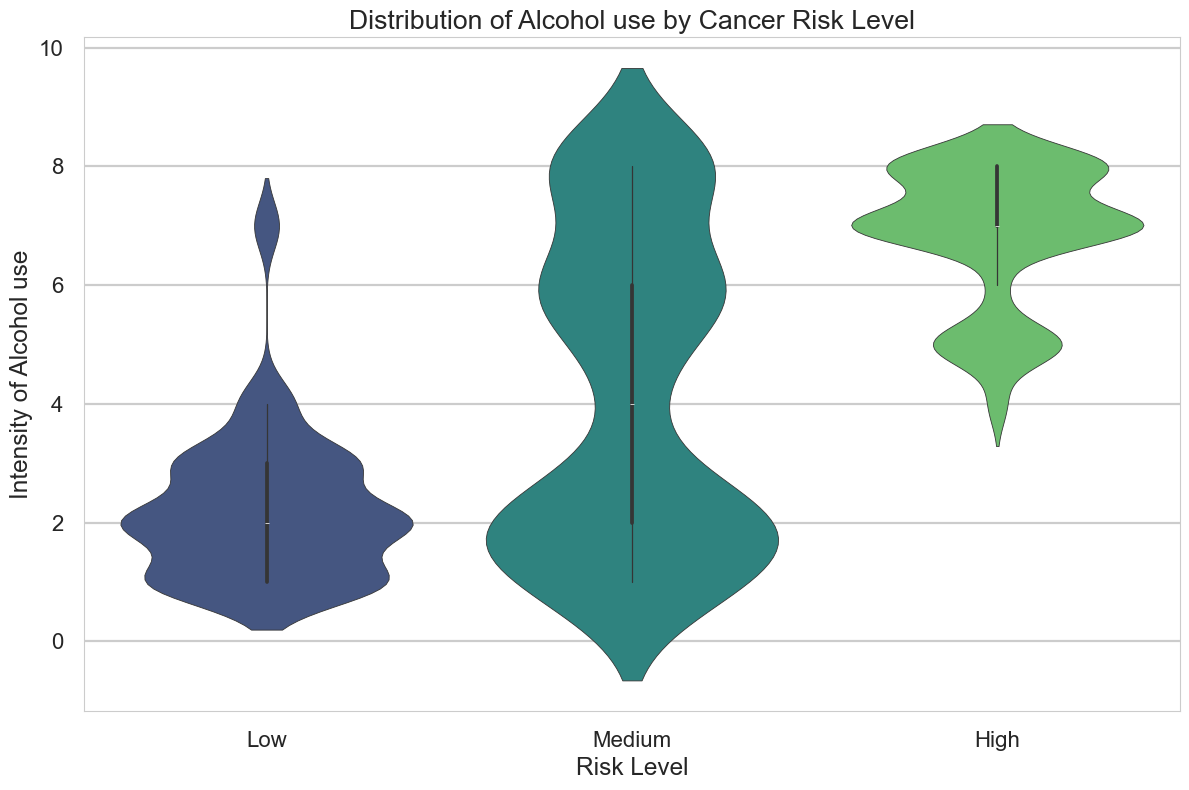

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2013587499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')


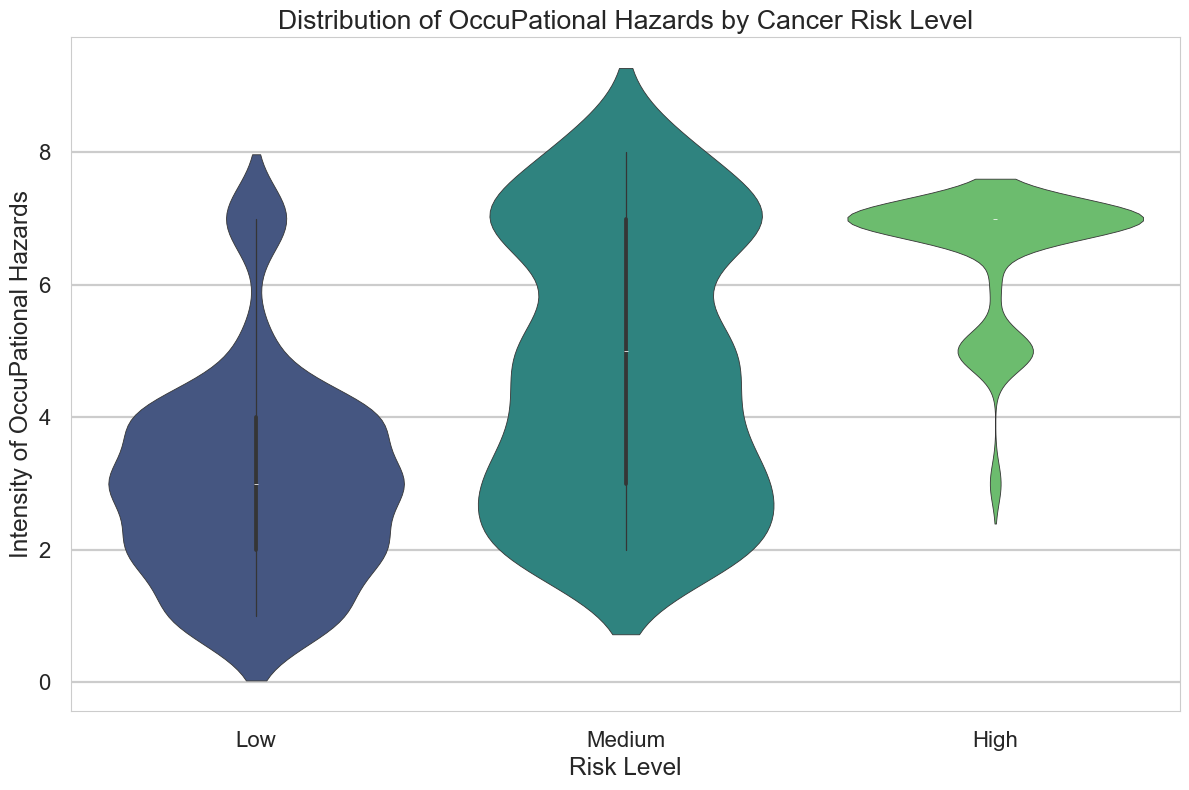

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2013587499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')


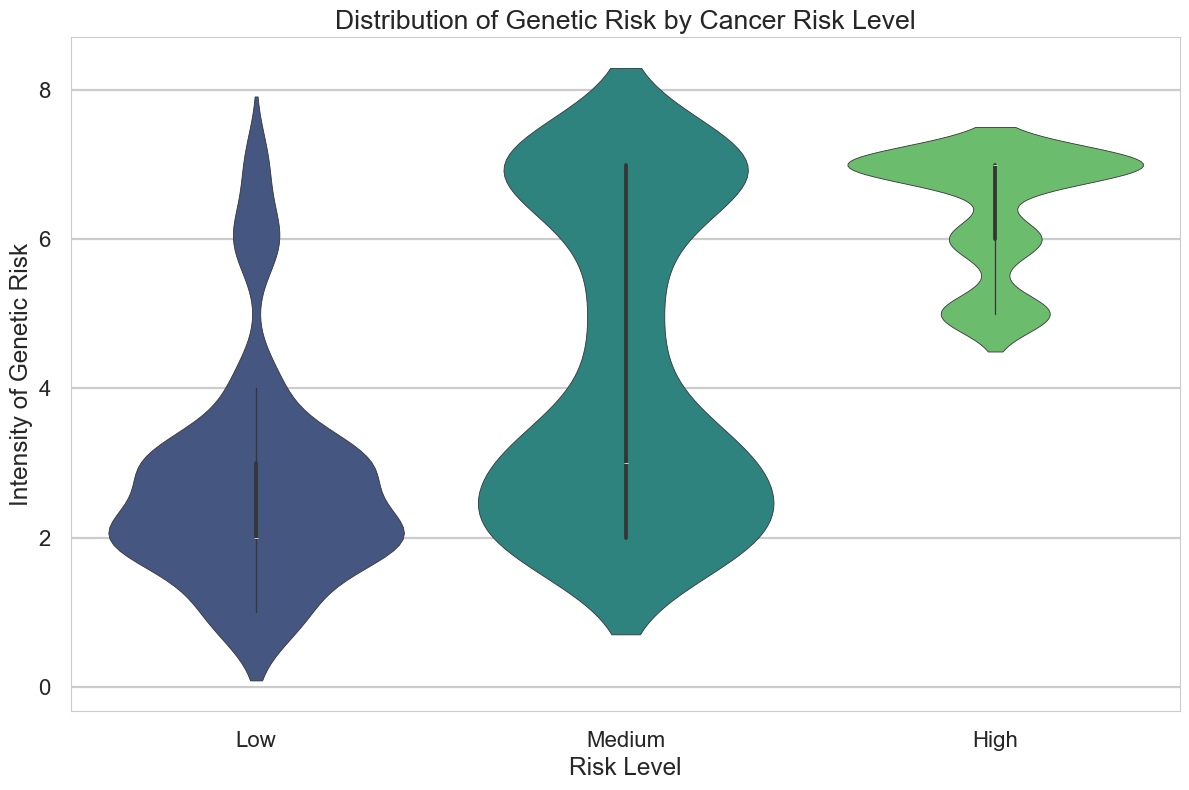

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2013587499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')


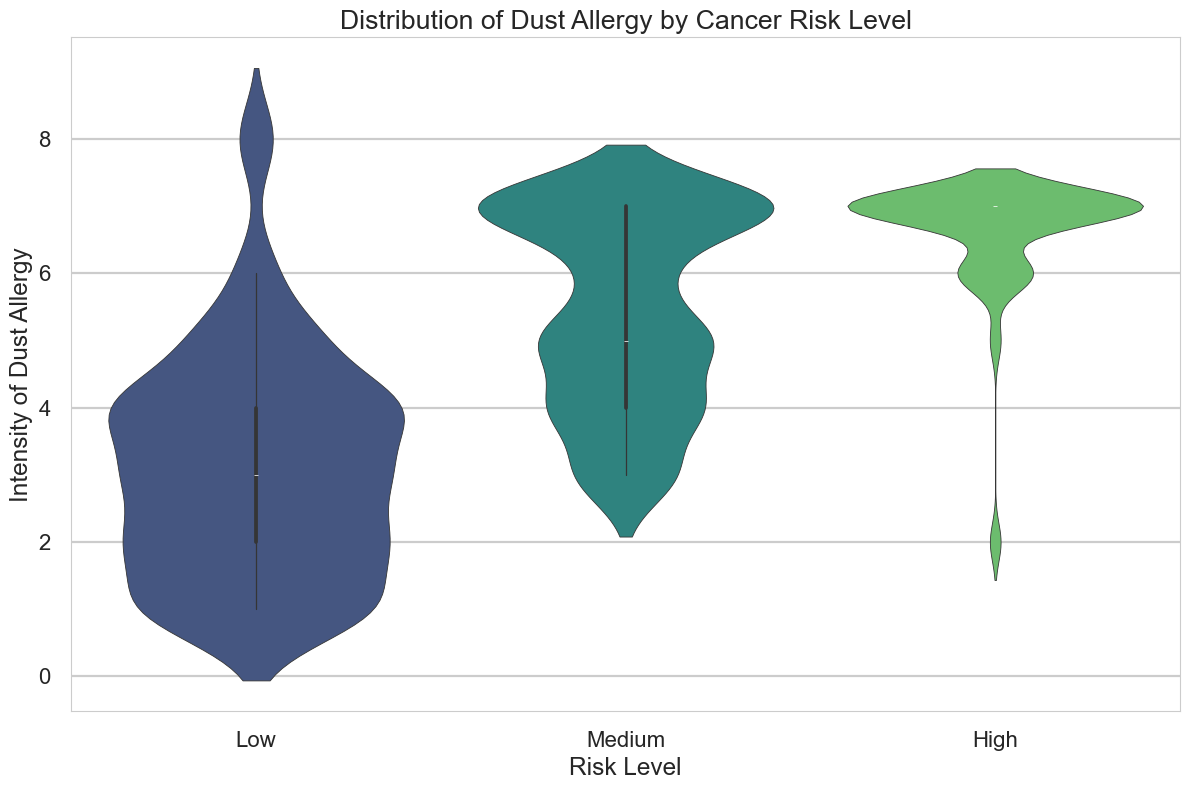

C:\Users\goopb\AppData\Local\Temp\ipykernel_44940\2013587499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')


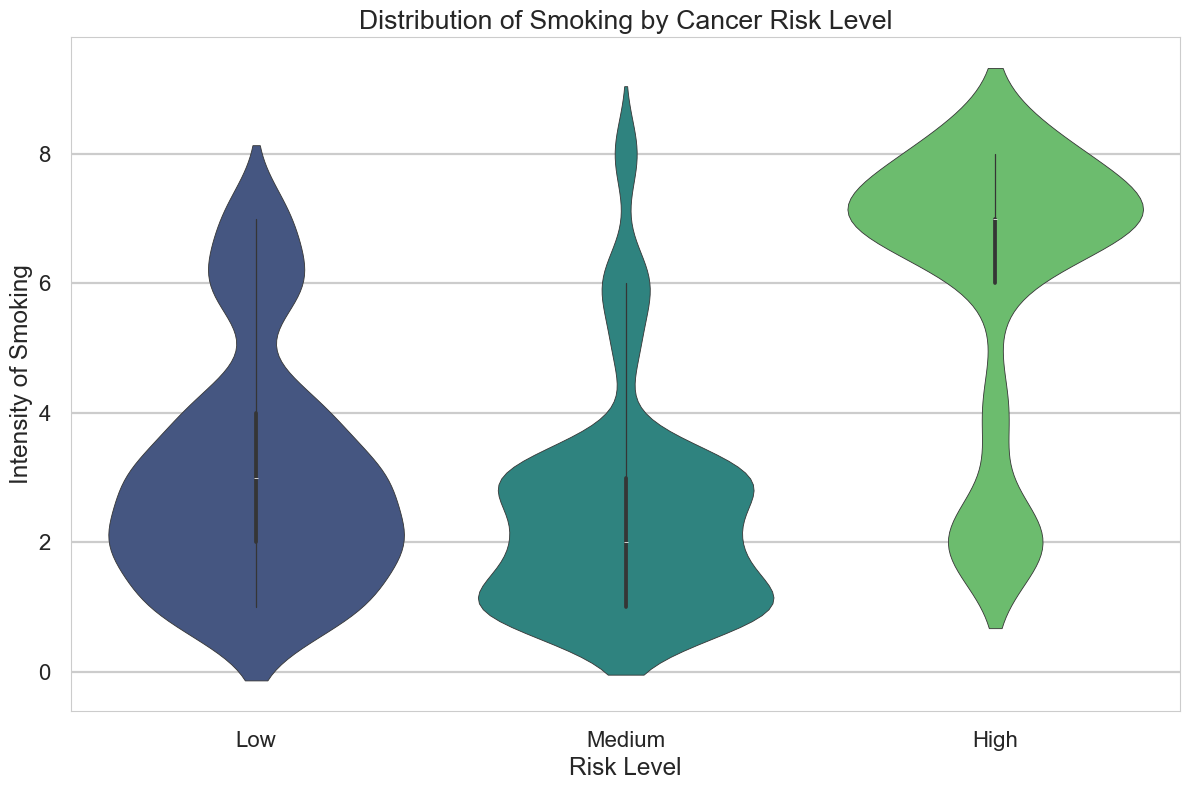

Displayed violin plots for top 5 correlated features.


In [24]:
# Violin plots combine a box plot with a kernel density plot, showing both
# the summary statistics and the distribution of the data.
print("\nPlotting violin plots for key features...")
top_corr_features = ['Alcohol use', 'OccuPational Hazards', 'Genetic Risk', 'Dust Allergy', 'Smoking']
for feature in top_corr_features:
    plt.figure(figsize=(12, 8))
    sns.violinplot(x='Level', y=feature, data=df, order=['Low', 'Medium', 'High'], palette='viridis')
    plt.title(f'Distribution of {feature} by Cancer Risk Level')
    plt.xlabel('Risk Level')
    plt.ylabel(f'Intensity of {feature}')
    plt.tight_layout()
    plt.show()
print("Displayed violin plots for top 5 correlated features.")


In [26]:
# We need to split our data into two parts:
# 1. Features (X): The input data (symptoms, habits, etc.).
# 2. Target (y): The output we want to predict (the cancer risk level).
# Then, we split it further into a training set (for teaching the model) and a
# testing set (for evaluating how well it learned).

print("\n--- Preparing Data for Machine Learning ---")
X = df.drop(['Level', 'Level_encoded'], axis=1)
y = df['Level_encoded']
print("Separated data into features (X) and target (y).")
# We use 80% of the data for training and 20% for testing.
# 'stratify=y' ensures that the proportion of Low, Medium, and High is the
# same in both the training and testing sets. This is crucial for imbalanced data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Data split into training ({len(X_train)} samples) and testing ({len(X_test)} samples) sets.")


--- Preparing Data for Machine Learning ---
Separated data into features (X) and target (y).
Data split into training (800 samples) and testing (200 samples) sets.



--- Training and Evaluating Machine Learning Models ---

----- Evaluating: Random Forest -----
Random Forest has been trained successfully.

Accuracy on Test Data: 100.00%

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



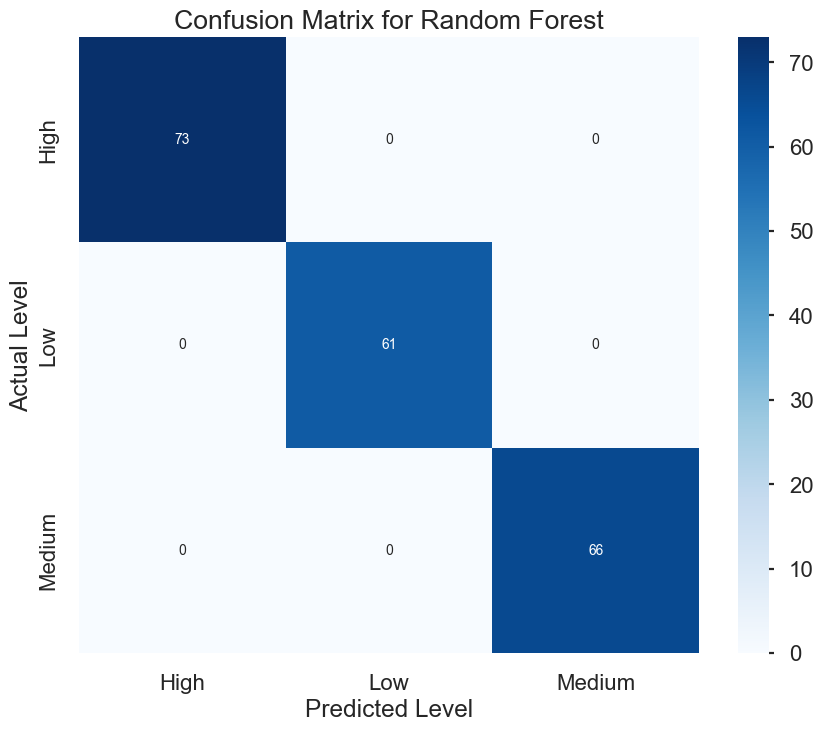

Displayed 'Random Forest_confusion_matrix' plot.

----- Evaluating: Gradient Boosting -----
Gradient Boosting has been trained successfully.

Accuracy on Test Data: 100.00%

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



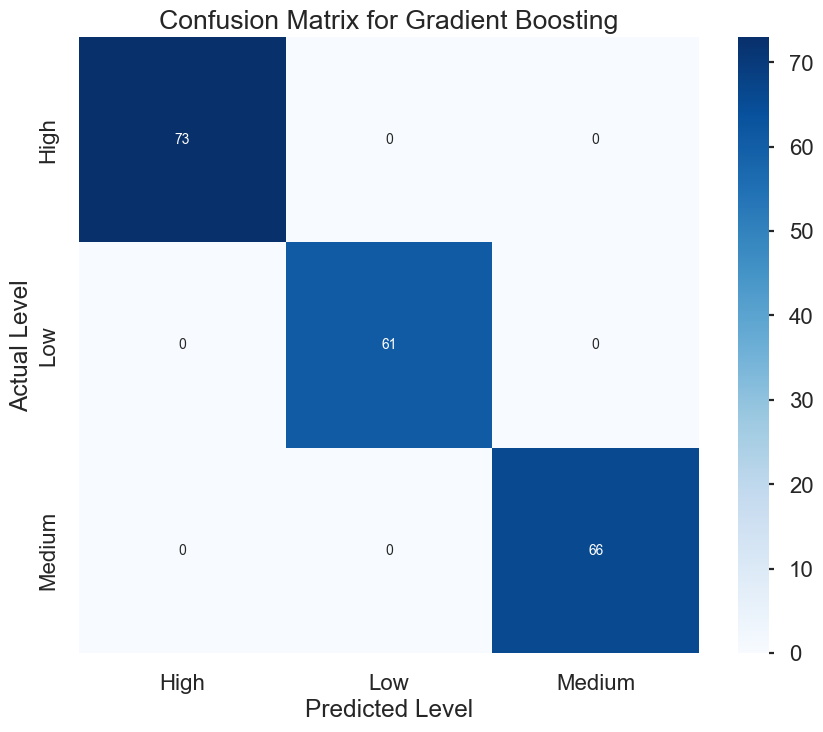

Displayed 'Gradient Boosting_confusion_matrix' plot.


In [27]:
# Step 5: Training and Evaluating Machine Learning Models
# ==============================================================================
# This is where the magic happens! We'll train two powerful models and see
# which one performs better on our data.

print("\n--- Training and Evaluating Machine Learning Models ---")

# We are choosing two excellent 'ensemble' models:
# 1. RandomForest: Works by creating many decision trees and taking a vote.
#    It's fast, robust, and great at preventing overfitting.
# 2. GradientBoosting: Builds trees one by one, where each new tree corrects
#    the errors of the previous one. It's often extremely accurate.
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
best_model = None
best_accuracy = 0

for model_name, model in models.items():
    print(f"\n----- Evaluating: {model_name} -----")
    
    # The .fit() method is where the model learns from the training data.
    model.fit(X_train, y_train)
    print(f"{model_name} has been trained successfully.")
    
    # The .predict() method makes predictions on the unseen test data.
    y_pred = model.predict(X_test)
    
    # We compare the model's predictions (y_pred) with the actual answers (y_test).
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"\nAccuracy on Test Data: {accuracy * 100:.2f}%")
    
    # The Classification Report gives us a detailed look at performance, including:
    # - Precision: Of all the times it predicted a level, how often was it right?
    # - Recall: Of all the actual cases of a level, how many did it find?
    # - F1-Score: A combined score of Precision and Recall.
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    # The Confusion Matrix visually shows us where the model got things right
    # and where it got confused.
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.ylabel('Actual Level')
    plt.xlabel('Predicted Level')
    plt.show()
    print(f"Displayed '{model_name}_confusion_matrix' plot.")


--- Final Model Comparison ---
               Model  Accuracy
0      Random Forest       1.0
1  Gradient Boosting       1.0


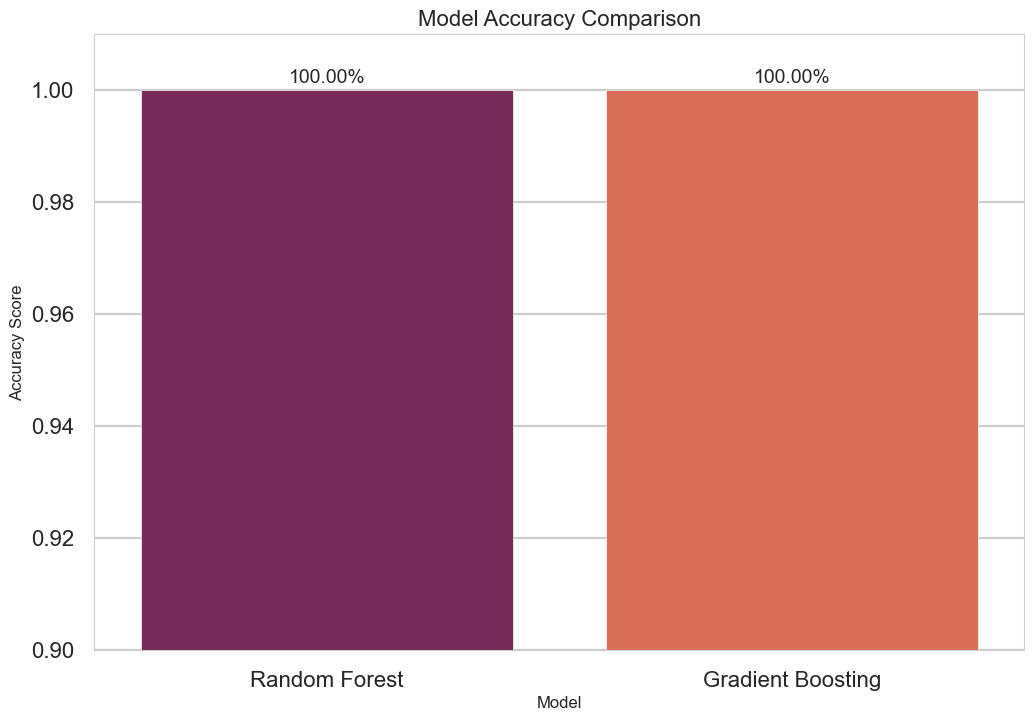

Displayed 'model_comparison' plot.


In [28]:
print("\n--- Final Model Comparison ---")
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)
print(results_df)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Model', y='Accuracy', data=results_df, palette='rocket', hue='Model', legend=False)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.9, 1.01)
for p in ax.patches:
    ax.annotate(f'{p.get_height() * 100:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=14)
plt.show()
print("Displayed 'model_comparison' plot.")



--- Feature Importance Analysis ---


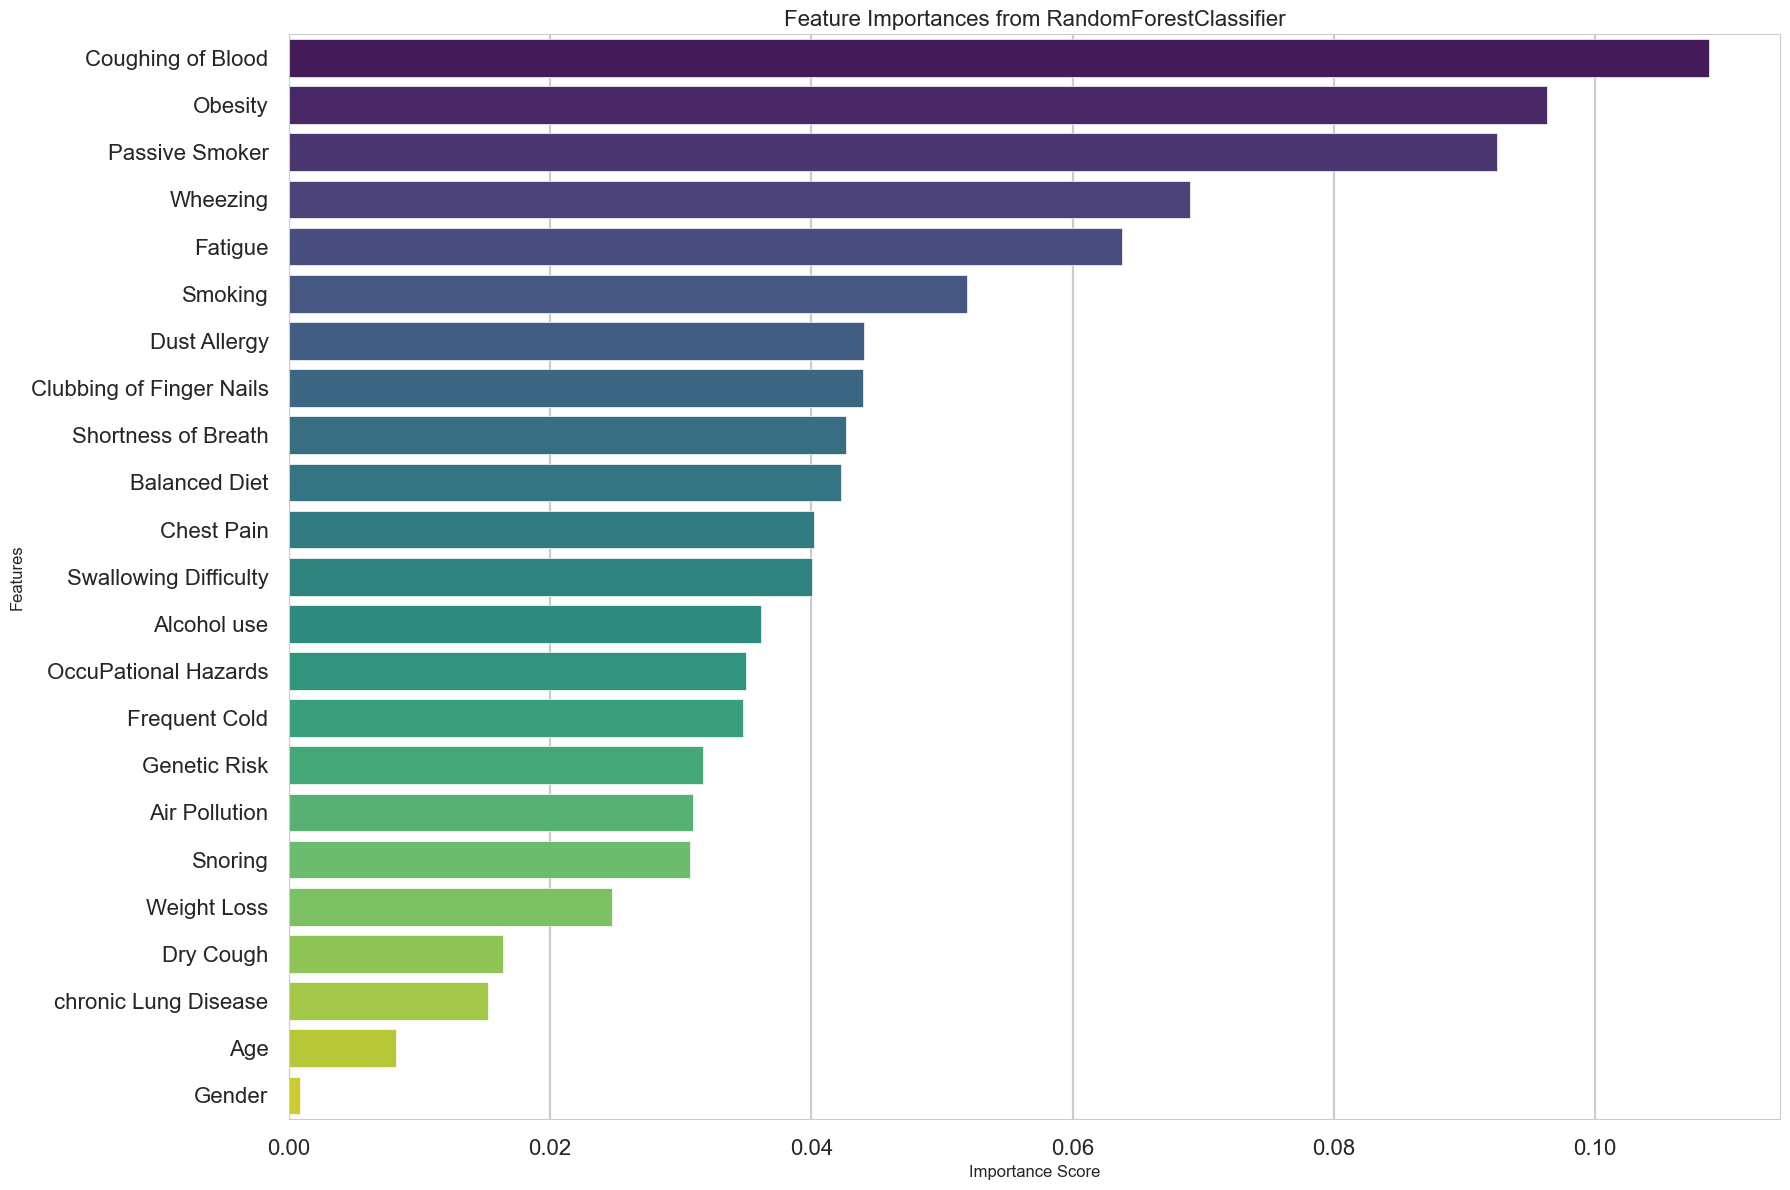

Displayed 'feature_importances' plot.

Most Important Features according to the best model:
                     Feature  Importance
13         Coughing of Blood    0.108726
9                    Obesity    0.096352
11            Passive Smoker    0.092527
17                  Wheezing    0.068955
14                   Fatigue    0.063759
10                   Smoking    0.051886
4               Dust Allergy    0.044032
19  Clubbing of Finger Nails    0.043964
16       Shortness of Breath    0.042637
8              Balanced Diet    0.042251
12                Chest Pain    0.040206
18     Swallowing Difficulty    0.040020


In [29]:
print("\n--- Feature Importance Analysis ---")
feature_importance_df = pd.DataFrame()
if best_model:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(18, 12))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
    plt.title(f'Feature Importances from {type(best_model).__name__}', fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("Displayed 'feature_importances' plot.")
    print("\nMost Important Features according to the best model:")
    print(feature_importance_df.head(12))
else:
    print("No model was trained successfully to show feature importances.")

In [30]:
# Now for the final part! We'll use our best model to make a prediction based
# on answers from the user.

print("\n--- Live Lung Cancer Risk Prediction ---")

def get_live_input(full_dataset, top_features_df):
    """Gathers user input for the most important features with validation."""
    print("\nPlease answer the following questions for a risk assessment.")
    user_data = {}
    top_features = top_features_df['Feature'].head(12).tolist()
    
    questions = {
        'Age': ("What is your current age? ", (1, 120)),
        'Gender': ("What is your gender? (Enter 1 for Male, 2 for Female): ", (1, 2)),
        'Air Pollution': ("On a scale of 1-10, how would you rate your daily exposure to Air Pollution? ", (1, 10)),
        'Alcohol use': ("On a scale of 1-8, how would you rate your alcohol consumption? ", (1, 8)),
        'Dust Allergy': ("How severe is your dust allergy? (Rate 1-8): ", (1, 8)),
        'OccuPational Hazards': ("How would you rate your exposure to occupational hazards? (Rate 1-8): ", (1, 8)),
        'Genetic Risk': ("How would you rate your genetic risk for cancer? (Rate 1-7): ", (1, 7)),
        'chronic Lung Disease': ("How severe is your chronic lung disease? (Rate 1-7): ", (1, 7)),
        'Balanced Diet': ("How would you rate the quality of your diet? (Rate 1-7): ", (1, 7)),
        'Obesity': ("How would you rate your level of obesity? (Rate 1-7): ", (1, 7)),
        'Smoking': ("How would you rate your smoking habits? (Rate 1-8): ", (1, 8)),
        'Passive Smoker': ("How would you rate your exposure as a passive smoker? (Rate 1-8): ", (1, 8)),
        'Chest Pain': ("How severe is your chest pain? (Rate 1-9): ", (1, 9)),
        'Coughing of Blood': ("How severe is your coughing of blood? (Rate 1-9): ", (1, 9)),
        'Fatigue': ("How would you rate your level of fatigue? (Rate 1-9): ", (1, 9)),
        'Weight Loss': ("How would you rate your unexplained weight loss? (Rate 1-8): ", (1, 8)),
        'Shortness of Breath': ("How severe is your shortness of breath? (Rate 1-9): ", (1, 9)),
        'Wheezing': ("How severe is your wheezing? (Rate 1-8): ", (1, 8)),
        'Swallowing Difficulty': ("How severe is your difficulty in swallowing? (Rate 1-8): ", (1, 8)),
        'Clubbing of Finger Nails': ("How severe is the clubbing of your finger nails? (Rate 1-9): ", (1, 9)),
        'Frequent Cold': ("How frequent are your colds? (Rate 1-7): ", (1, 7)),
        'Dry Cough': ("How severe is your dry cough? (Rate 1-7): ", (1, 7)),
        'Snoring': ("How severe is your snoring? (Rate 1-7): ", (1, 7))
    }
    
    print("\n--- Please answer the most important questions ---")
    for feature in top_features:
        while True:
            try:
                prompt, (min_val, max_val) = questions.get(feature, (f"Enter value for {feature}: ", (None, None)))
                val = int(input(prompt))
                if min_val is not None and not (min_val <= val <= max_val):
                    print(f"Invalid input. Please enter a number between {min_val} and {max_val}.")
                    continue
                user_data[feature] = val
                break
            except ValueError:
                print("Invalid input. Please enter a whole number.")

    all_features = full_dataset.drop(['Level', 'Level_encoded'], axis=1).columns
    for feature in all_features:
        if feature not in user_data:
            user_data[feature] = round(full_dataset[feature].mean())
    
    return user_data

try:
    if not feature_importance_df.empty:
        live_input = get_live_input(df, feature_importance_df)
        input_df = pd.DataFrame([live_input])
        input_df = input_df[X.columns]

        prediction_encoded = best_model.predict(input_df)
        prediction_proba = best_model.predict_proba(input_df)
        
        prediction_label = le.inverse_transform(prediction_encoded)
        confidence = prediction_proba[0][prediction_encoded[0]] * 100

        print("\n--- Prediction Result ---")
        print(f"The model predicts a '{prediction_label[0]}' risk level for lung cancer.")
        print(f"Confidence: {confidence:.2f}%")
        
        print("\n*** IMPORTANT DISCLAIMER ***")
        print("This prediction is based on a machine learning model and is for educational purposes only.")
        print("It is NOT a substitute for professional medical advice. Please consult a doctor for an accurate diagnosis.")
    else:
        print("\nCould not run live prediction as feature importance was not determined.")

except (KeyboardInterrupt, EOFError):
    print("\n\nPrediction cancelled by user.")


print("\n--- Analysis Complete ---")


--- Live Lung Cancer Risk Prediction ---

Please answer the following questions for a risk assessment.

--- Please answer the most important questions ---


How severe is your coughing of blood? (Rate 1-9):  1
How would you rate your level of obesity? (Rate 1-7):  5
How would you rate your exposure as a passive smoker? (Rate 1-8):  3
How severe is your wheezing? (Rate 1-8):  1
How would you rate your level of fatigue? (Rate 1-9):  1
How would you rate your smoking habits? (Rate 1-8):  3
How severe is your dust allergy? (Rate 1-8):  


Invalid input. Please enter a whole number.


How severe is your dust allergy? (Rate 1-8):  1
How severe is the clubbing of your finger nails? (Rate 1-9):  1
How severe is your shortness of breath? (Rate 1-9):  5
How would you rate the quality of your diet? (Rate 1-7):  4
How severe is your chest pain? (Rate 1-9):  1
How severe is your difficulty in swallowing? (Rate 1-8):  1



--- Prediction Result ---
The model predicts a 'Low' risk level for lung cancer.
Confidence: 54.00%

*** IMPORTANT DISCLAIMER ***
This prediction is based on a machine learning model and is for educational purposes only.
It is NOT a substitute for professional medical advice. Please consult a doctor for an accurate diagnosis.

--- Analysis Complete ---
